### Scrapping news headlines

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
%matplotlib inline
#import seaborn as sns

from urllib.request import urlopen, Request
import requests
from bs4 import BeautifulSoup as bs

!pip install -U nltk[all]
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import datetime as dt

!pip install yfinance
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from numpy import quantile, where, random
from sklearn.covariance import EllipticEnvelope

from mpl_toolkits.axes_grid1 import host_subplot
from mpl_toolkits.mplot3d import Axes3D
import mpl_toolkits.axisartist as AA

import warnings
warnings.filterwarnings("ignore")

# https://programminghistorian.org/en/lessons/sentiment-analysis
# https://www.nltk.org/_modules/nltk/sentiment/vader.html

### Stock - The Boeing Co. (BA)

In [ ]:
"""mediumTitle1s = {}

url = 'https://www.investing.com/equities/boeing-co-news/'
#print(url)

for page in range(1, 3):
  req = Request(url=url + str(page), headers={'user-agent': 'my-app'})
  #req = Request(url=url + str(page), headers={'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/89.0.4389.90 Safari/537.36'})
  response = urlopen(req)
  html = bs(response, features='html.parser')
  mediumTitle1 = html.find_all(lambda tag: tag.name == 'div' and tag.get('class') == ['mediumTitle1'])
  mediumTitle1s[page] = mediumTitle1  #key is 'page' in dictionary 'mediumTitels

#mediumTitle1s  """

In [ ]:
#len(mediumTitle1s)

In [ ]:
"""data_news = []

for page, mediumTitle1 in mediumTitle1s.items():
  #print(page, mediumTitle1)

  for article in mediumTitle1:
    for article in article.find_all('article', {'class': "js-article-item articleItem "}):
      title = article.find('a', {'class': "title"}).text
    #for title in article.find_all('a', {'class': "title"}):
      #print(title)

      for article in article.find_all('span', {'class': "articleDetails"}):
        date = article.find('span', {'class': "date"}).text[3:15]
        #print(date)

      data_news.append([page, 'BA', date, title])  """

In [ ]:
#len(data_news)

In [ ]:
"""path = r'/content/drive/MyDrive/Colab Notebooks/Stock news_investment/BoeingCo'                     # use your path
all_files = glob.glob(os.path.join(path, "*.csv"))     # advisable to use os.path.join as this makes concatenation OS independent

df_from_each_file = (pd.read_csv(f) for f in all_files)
df_concatenated_ba   = pd.concat(df_from_each_file, ignore_index=True)
df_concatenated_ba"""

'path = r\'/content/drive/MyDrive/Colab Notebooks/Stock news_investment/BoeingCo\'                     # use your path\nall_files = glob.glob(os.path.join(path, "*.csv"))     # advisable to use os.path.join as this makes concatenation OS independent\n\ndf_from_each_file = (pd.read_csv(f) for f in all_files)\ndf_concatenated_ba   = pd.concat(df_from_each_file, ignore_index=True)\ndf_concatenated_ba'

In [ ]:
"""# Saving combination of new headlines of Boeing co in G-drive

ba_news_final_combo = df_concatenated_ba.to_csv('/content/drive/MyDrive/Colab Notebooks/Stock news_investment/BoeingCo/ba_news_final_combo.csv')"""

"# Saving combination of new headlines of Boeing co in G-drive\n\nba_news_final_combo = df_concatenated_ba.to_csv('/content/drive/MyDrive/Colab Notebooks/Stock news_investment/BoeingCo/ba_news_final_combo.csv')"

### Reading extracted news Headlines file from G-drive for The Boeing co. stocks

In [ ]:
df_concatenated_ba = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Stock news_investment/BoeingCo/ba_news_final_combo.csv')

In [ ]:
df_concatenated_ba.info()

In [ ]:
# Checking Nan values

df_concatenated_ba.isna().sum()

In [ ]:
# deleting Nan values and rechecking NaN in column 'date'

df_concatenated_ba = df_concatenated_ba.dropna()
df_concatenated_ba.isna().sum()

Unnamed: 0      0
Unnamed: 0.1    0
page            0
company         0
date            0
title           0
dtype: int64

In [ ]:
# dropping unwanted column

df_concatenated_ba = df_concatenated_ba.drop(columns='Unnamed: 0')
df_concatenated_ba.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3104 entries, 0 to 3107
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0.1  3104 non-null   int64 
 1   page          3104 non-null   int64 
 2   company       3104 non-null   object
 3   date          3104 non-null   object
 4   title         3104 non-null   object
dtypes: int64(2), object(3)
memory usage: 145.5+ KB


In [ ]:
# converting dtype of column 'date'

df_concatenated_ba['date'] = pd.to_datetime(df_concatenated_ba['date'], dayfirst=True, errors='coerce')
df_concatenated_ba.info()

In [ ]:
df_concatenated_ba.head()

,Unnamed: 0.1,page,company,date,title
0,0,99,BA,2020-06-28,Exclusive: Boeing 737 MAX certification flight...
1,1,99,BA,2020-06-27,China's big three airlines take delivery of do...
2,2,99,BA,2020-06-26,Boeing 737 MAX certification flight test expec...
3,3,99,BA,2020-06-26,France confirms it will read black boxes of do...
4,4,99,BA,2020-06-26,Spirit AeroSystems extends Boeing 737 furlough...


In [ ]:
# resetting index

df_concatenated_ba = df_concatenated_ba.reset_index(drop=True)  # reset index here, by default index column will be reset in ascending order
df_concatenated_ba.head()

,Unnamed: 0.1,page,company,date,title
0,0,99,BA,2020-06-28,Exclusive: Boeing 737 MAX certification flight...
1,1,99,BA,2020-06-27,China's big three airlines take delivery of do...
2,2,99,BA,2020-06-26,Boeing 737 MAX certification flight test expec...
3,3,99,BA,2020-06-26,France confirms it will read black boxes of do...
4,4,99,BA,2020-06-26,Spirit AeroSystems extends Boeing 737 furlough...


In [ ]:
# Saving combination of CLEANED news headlines of Boeing co in G-drive

ba_news_final_combo_cleaned = df_concatenated_ba.to_csv('/content/drive/MyDrive/Colab Notebooks/Stock news_investment/BoeingCo/ba_news_final_combo_cleaned.csv')

In [ ]:
df_concatenated_ba

### Testing the polarity rates of the random sentences with Emojis, Slang and Emoticons

In [ ]:
# testing the polarity rate of a random sentence

vader = SentimentIntensityAnalyzer()
print(vader.polarity_scores("Google is a good company but not a good idea to invest now."))

In [ ]:
# testing the polarity rate of a random sentence with Emojis

vader = SentimentIntensityAnalyzer()
print(vader.polarity_scores("Today its sunny again, I am 😊😄!"))

In [ ]:
# testing the polarity rate of a random sentence with Slang

vader = SentimentIntensityAnalyzer()
print(vader.polarity_scores("It sucks!"))

In [ ]:
# testing the polarity rate of a random sentence with Emoticons

vader = SentimentIntensityAnalyzer()
print(vader.polarity_scores("It feels like a :( day!"))

In [ ]:
column_compound = lambda title: vader.polarity_scores(title)['compound']
#df_current_data_news['compound'] = df_current_data_news['title'].apply(column_compound)
df_concatenated_ba['compound_pol_ba'] = df_concatenated_ba['title'].apply(column_compound)
df_concatenated_ba

In [ ]:
df_concatenated_ba = df_concatenated_ba.drop(columns={'Unnamed: 0.1', 'page'})
df_concatenated_ba.head()

In [ ]:
df_concatenated_ba.describe()

In [ ]:
df_concatenated_ba.info()

### Visualizing the data of Boeing Co. stock news sentiments

In [ ]:
#df_concatenated_ba['date'] = pd.to_datetime(df_concatenated_ba.date).dt.date  # parsing date using to_datetime

mean_df_concatenated_ba = df_concatenated_ba.groupby(['company', 'date']).mean()  #grouping by date and company and then calculating the mean of the compound polarity of Boeing
mean_df_concatenated_ba

In [ ]:
mean_df_concatenated_ba = mean_df_concatenated_ba.unstack()
mean_df_concatenated_ba = mean_df_concatenated_ba.xs('compound_pol_ba', axis="columns").transpose()  # transposing date and title on x and y axes respectively
mean_df_concatenated_ba

company,BA
date,
2019-03-01,0.000000
2019-03-02,0.000000
2019-03-04,0.137300
2019-03-05,-0.180600
2019-03-06,-0.106067
...,...
2021-03-25,-0.196240
2021-03-26,-0.113150
2021-03-29,-0.067764


In [ ]:
mean_df_concatenated_ba.info()

In [ ]:
mean_df_concatenated_ba = mean_df_concatenated_ba.reset_index('date')
mean_df_concatenated_ba['date'] = pd.to_datetime(mean_df_concatenated_ba['date'])
mean_df_concatenated_ba = mean_df_concatenated_ba.rename(columns={'date': 'Date'})
mean_df_concatenated_ba.info()

In [ ]:
fig = px.bar(mean_df_concatenated_ba, x='Date', y='BA', title='<b>News sentiments polarity of Boeing from 2019 to 2021', labels={'BA': 'Compound Polarity rate (Boeing co.)'})
#, title='<b>Compounded sentiment polarity of news Headlines of company-The Boeing Co (BA) Stock from year 2019 to 2021'</b>', labels={'BA': 'Compound polarity rate - The Boeing co.'}
fig.update_layout(title_x=0.5)  # to center the title
fig.update_xaxes(rangeslider_visible=True, )
fig.show()

In [ ]:
"""# Plotting the data on Boeing's news sentiments

#sns.set_style('darkgrid')

mean_df_concatenated_ba.plot(kind='bar', figsize=(20,9), title='Compounded sentiment polarity of news Headlines of company-The Boeing Co (BA) Stock from year 2019 to 2021', ylabel='Compound Polarity rate', color=['blue'])
plt.show()"""

### Pulling historical stock prices of The Boeing co. from Yahoo finance

In [ ]:
# Pulling historical stock prices of The Boeing Co from Yahoo finance

ba = yf.Ticker("BA")

ba_historical = ba.history(start="2019-03-01", end="2021-04-01", interval="1d")  # Daily stock price
ba_historical


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-03-01,435.563760,435.563760,429.880066,430.299988,5124200,0.0,0
2019-03-04,432.839095,434.089114,416.637662,422.555725,5971000,0.0,0
2019-03-05,420.944364,423.688547,418.600581,420.045898,2844300,0.0,0
2019-03-06,419.635754,421.881873,412.194202,414.518463,4159400,0.0,0
2019-03-07,413.444215,424.176831,406.686309,412.662964,4893600,0.0,0
...,...,...,...,...,...,...,...
2021-03-25,234.339996,247.580002,231.699997,247.190002,27553600,0.0,0
2021-03-26,249.619995,250.899994,240.300003,244.869995,17157100,0.0,0
2021-03-29,251.300003,254.710007,248.029999,250.520004,22198800,0.0,0


In [ ]:
ba_historical = ba_historical.reset_index('Date')

In [ ]:
ba_historical.info()

In [ ]:
ba_historical = ba_historical.drop(columns=['High', 'Low', 'Dividends', 'Stock Splits'])
ba_historical

,Date,Open,Close,Volume
0,2019-03-01,435.563760,430.299988,5124200
1,2019-03-04,432.839095,422.555725,5971000
2,2019-03-05,420.944364,420.045898,2844300
3,2019-03-06,419.635754,414.518463,4159400
4,2019-03-07,413.444215,412.662964,4893600
...,...,...,...,...
521,2021-03-25,234.339996,247.190002,27553600
522,2021-03-26,249.619995,244.869995,17157100
523,2021-03-29,251.300003,250.520004,22198800
524,2021-03-30,251.240005,252.009995,12577300


In [ ]:
"""# Plotting Close price

#sns.set_style("darkgrid")
plt.figure(figsize=(15,6))
plt.plot(ba_historical['Date'], ba_historical['Close'], color='red', label='Close price')
plt.title("Stock prices of The Boeing Co from 2019 to 2021", fontsize = 16)
plt.xlabel('Dates', fontsize = 18)
plt.xticks(x = 'Date', rotation = 90)
#plt.margins(0.2)
plt.ylabel('Prices in USD', fontsize = 18)
plt.legend(fontsize=15)
#plt.fill_between(x, 'Close')
plt.show()

# Plotting Traded volume

#sns.set_style("darkgrid")
plt.figure(figsize=(15,6))
plt.plot(ba_historical['Date'], ba_historical['Volume'], label='Traded Volumes', color='blue')
plt.title("Traded volumes of The Boeing Co stock from 2019 to 2021", fontsize = 16)
plt.xlabel('Dates', fontsize = 18)
plt.xticks(x = 'Date', rotation = 90)
#plt.margins(0.2)
plt.ylabel('Volume', fontsize = 18)
plt.legend(fontsize=15)
#plt.fill_between('Date', 'Close')
plt.show()"""

In [ ]:
# Plotting Close price

fig = px.line(ba_historical, x='Date', y='Close', title='<b>Stock prices of The Boeing Co from 2019 to 2021</b>', labels={'Close': 'Stock prices in USD - The Boeing co.'})
fig.update_layout(title_x=0.5)  # to center the title
fig.update_xaxes(rangeslider_visible=True, )
fig.show()

# Plotting Traded volume

fig = px.line(ba_historical, x='Date', y='Volume', title='<b>Traded volumes of The Boeing Co stock from 2019 to 2021</b>', labels={'Volume': 'Traded volumes - The Boeing co.'})
fig.update_layout(title_x=0.5)  # to center the title
fig.update_xaxes(rangeslider_visible=True, )
fig.show()

In [ ]:
#Checking where the Close price is greater then Open price

ba_historical['Bool_Close_&_Price'] = ba_historical['Close'].gt(ba_historical['Open'])
ba_historical

In [ ]:
# Changing Boolean values to Integer

ba_historical['Binary_Close_&_Price'] = ba_historical['Bool_Close_&_Price'].astype(int)
ba_historical

In [ ]:
mean_df_concatenated_ba.head()

In [ ]:
# Concatenating Stock prices and Compound Polarity rate of The Boeing Co

#ba_historical_new = pd.concat((pfe_historical, mean_df_clubbed_news_pfe), axis=1)
ba_historical_new = ba_historical.merge(mean_df_concatenated_ba, how='outer')
#ba_historical_new = mean_df_pfe.merge(ba_historical, how='outer')
ba_historical_new = ba_historical_new.sort_values(by=['Date'])
ba_historical_new

In [ ]:
# Deleting all the rows containing NaN

ba_historical_new = ba_historical_new.dropna()

In [ ]:
ba_historical_new.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 503 entries, 0 to 525
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  503 non-null    datetime64[ns]
 1   Open                  503 non-null    float64       
 2   Close                 503 non-null    float64       
 3   Volume                503 non-null    float64       
 4   Bool_Close_&_Price    503 non-null    object        
 5   Binary_Close_&_Price  503 non-null    float64       
 6   BA                    503 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 31.4+ KB


In [ ]:
ba_historical_new.isna().sum()

In [ ]:
# Converting dtype of 'Binary_Close_&_Price' ton integer

ba_historical_new['Binary_Close_&_Price'] = ba_historical_new['Binary_Close_&_Price'].astype(int)

In [ ]:
ba_historical_new.info()

In [ ]:
ba_historical_new

In [ ]:
ba_historical_new.describe()

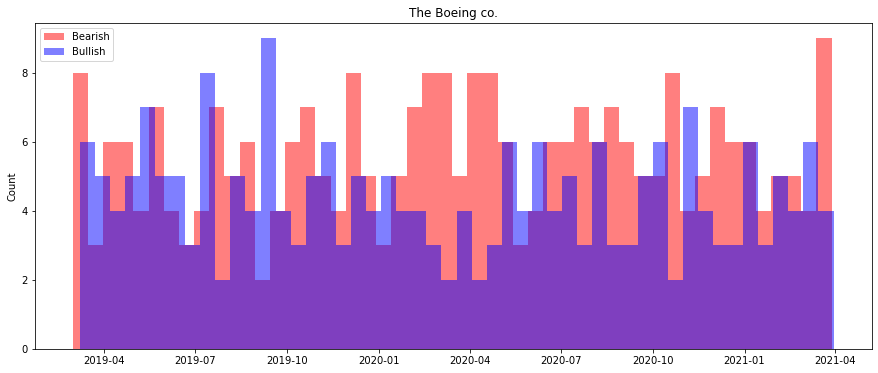

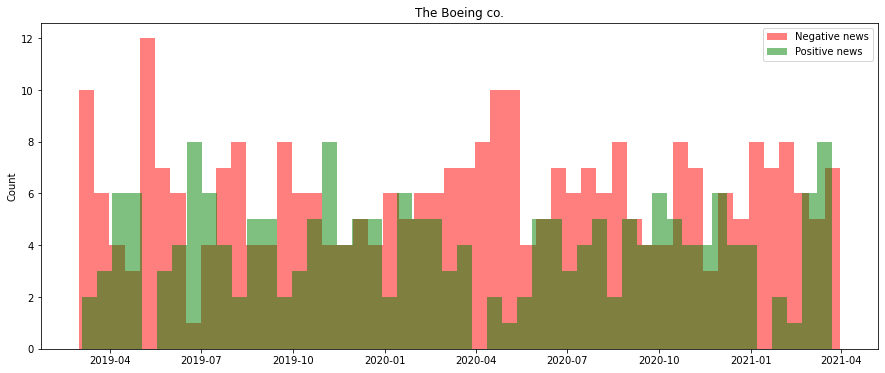

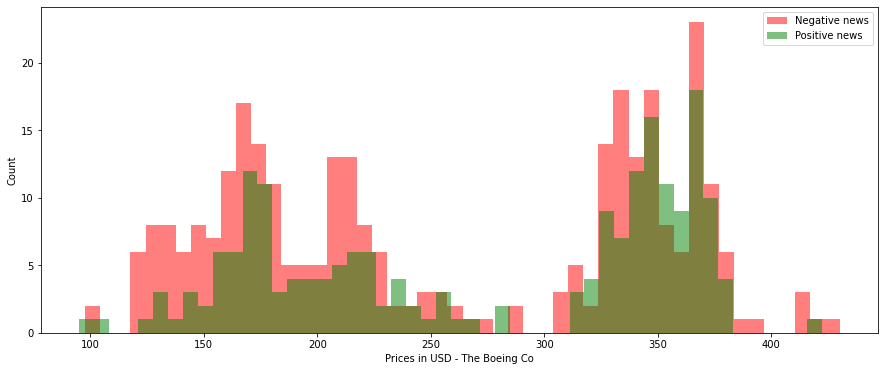

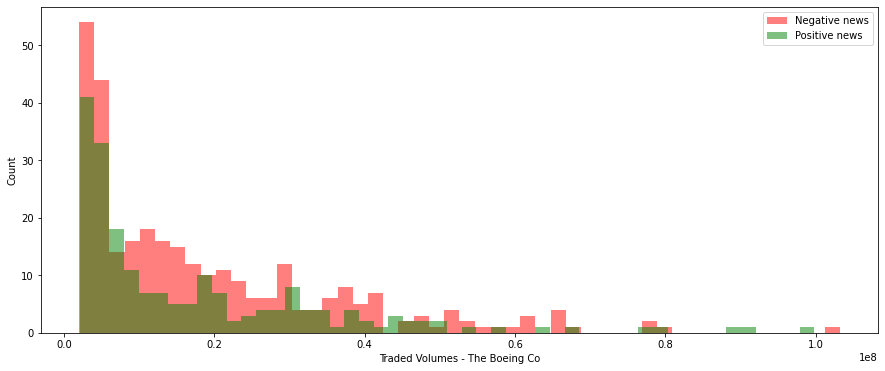

In [ ]:
#sns.set_style("darkgrid")
a = ba_historical_new.loc[ba_historical_new['Binary_Close_&_Price'] == 0, 'Date']  # When C.P < O.P, Bearish = market down
b = ba_historical_new.loc[ba_historical_new['Binary_Close_&_Price'] == 1, 'Date']  # When C.P > O.P, Bullish = market up
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Bearish', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Bullish', color='blue')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.title('The Boeing co.')
#plt.xlabel('Date')
plt.ylabel('Count')
plt.show()

#sns.set_style("darkgrid")
a = ba_historical_new.loc[ba_historical_new['BA'] <= 0, 'Date']  # BA < 0, means Negative News
b = ba_historical_new.loc[ba_historical_new['BA'] > 0, 'Date']  # BA > 0, means Positive News
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Negative news', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Positive news', color='green')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.title('The Boeing co.')
#plt.xlabel('Price - The Boeing Co')
plt.ylabel('Count')
plt.show()

a = ba_historical_new.loc[ba_historical_new['BA'] <= 0, 'Close']  # BA < 0, means Negative News
b = ba_historical_new.loc[ba_historical_new['BA'] > 0, 'Close']  # BA > 0, means Positive News
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Negative news', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Positive news', color='green')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.xlabel('Prices in USD - The Boeing Co')
plt.ylabel('Count')
plt.show()

#sns.set_style("darkgrid")
a = ba_historical_new.loc[ba_historical_new['BA'] <= 0, 'Volume']  # BA < 0, means Negative News
b = ba_historical_new.loc[ba_historical_new['BA'] > 0, 'Volume']  # BA > 0, means Positive News
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Negative news', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Positive news', color='green')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.xlabel('Traded Volumes - The Boeing Co')
plt.ylabel('Count')
plt.show()

From the plot above:
1. When the market is Bearish, we can see high trading volumes
2. With positive news, maximum number of time the prices can be seen high.

In [ ]:
# Bullish v/s Bearish market in span of two years from 2019 to 2021

ba_historical_new['Binary_Close_&_Price'].value_counts()

0    280
1    223
Name: Binary_Close_&_Price, dtype: int64

### Anomaly Detection by Isolation Forest - The Boeing Co stock

In [ ]:
# The important features for our analysis are "Close", "Compounded polarity" and "Binary_Close_&_Price"

data = ba_historical_new[['Close']]

sc = MinMaxScaler()
scaled = sc.fit_transform(data)  # scaling the data for fitting
data = pd.DataFrame(scaled)

# Building and training model with Isolation forest

outliers_fraction = 0.05  # Trying to detect 5% observations which may be different from the rest of our data.

model =  IsolationForest(contamination=outliers_fraction)
model.fit(data)

ba_historical_new['anomaly_IsolationForest'] = pd.Series(model.predict(data))
# ba_historical_new['anomaly_IsolationForest'] = ba_historical_new['anomaly_IsolationForest'].map( {1: 0, -1: 1} )


In [ ]:
ba_historical_new.head()

In [ ]:
ba_historical_new.info()

In [ ]:
# Counting distinct number of anomalies in "traded Volumes" of The Boeiing company stock

ba_historical_new.loc[ba_historical_new['anomaly_IsolationForest'] == -1,'anomaly_IsolationForest'].agg(['count'])

In [ ]:
anomaly_IF_BA = ba_historical_new.loc[ba_historical_new['anomaly_IsolationForest'].values == -1]
anomaly_IF_BA

In [ ]:
# Saving the results of anomalies by Isolation Forest in G-drive

anomaly_IF_BA_gdrive = anomaly_IF_BA.to_csv('/content/drive/MyDrive/Colab Notebooks/Results of Anamoly detection/Result_IsolationForest/Result_IF_BA.csv')

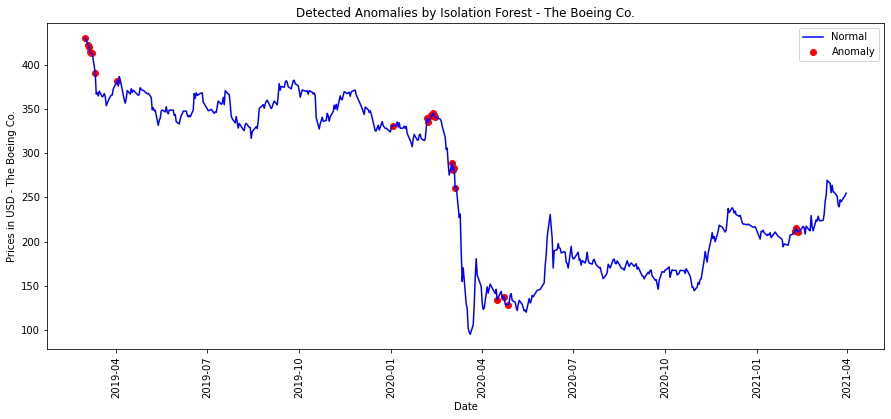

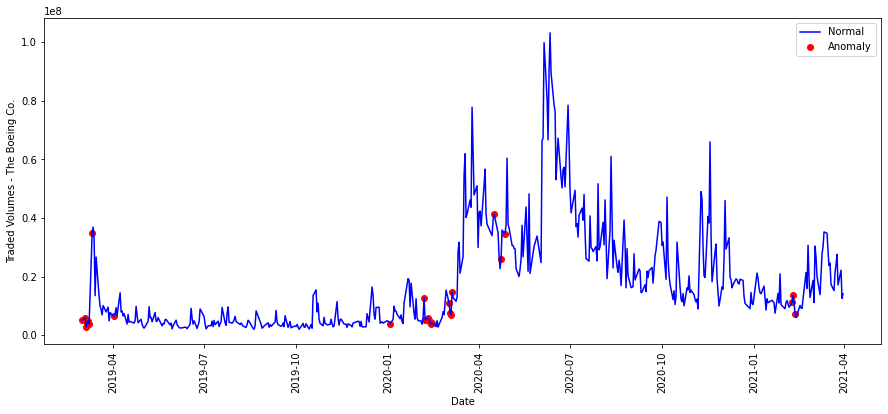

In [ ]:
# Plotting

fig, ax = plt.subplots(figsize=(15,6))

a = ba_historical_new.loc[ba_historical_new['anomaly_IsolationForest'] == -1, ['Date', 'Close']] #anomaly

#sns.set_style("darkgrid")
ax.plot(ba_historical_new['Date'], ba_historical_new['Close'], color='blue', label = 'Normal')
ax.scatter(a['Date'],a['Close'], color='red', label = 'Anomaly')
plt.legend()
plt.title('Detected Anomalies by Isolation Forest - The Boeing Co.')
plt.xlabel('Date')
plt.xticks(rotation=90)
plt.ylabel('Prices in USD - The Boeing Co.')
plt.show()

fig, ax = plt.subplots(figsize=(15,6))

a = ba_historical_new.loc[ba_historical_new['anomaly_IsolationForest'] == -1, ['Date', 'Volume']] #anomaly

#sns.set_style("darkgrid")
ax.plot(ba_historical_new['Date'], ba_historical_new['Volume'], color='blue', label = 'Normal')
ax.scatter(a['Date'],a['Volume'], color='red', label = 'Anomaly')
plt.legend()
plt.xlabel('Date')
plt.xticks(rotation=90)
plt.ylabel('Traded Volumes - The Boeing Co.')
plt.show()

### One-Class SVM anomaly detection - The Boeing co stock

In [ ]:
data = ba_historical_new[['Close']]

sc = MinMaxScaler()
scaled = sc.fit_transform(data)
data = pd.DataFrame(scaled)

# Building and training One-class SVM model

model = OneClassSVM(nu=outliers_fraction, kernel="rbf", gamma=0.01)
model.fit(data)
ba_historical_new['anomaly_OneClassSVM'] = pd.Series(model.predict(data)) # -1 is anomaly and 1 is normal.

In [ ]:
ba_historical_new.head()

In [ ]:
# Counting distinct number of anomalies in "The Boeing co. stock Prices"

ba_historical_new.loc[ba_historical_new['anomaly_OneClassSVM'] == -1,'anomaly_OneClassSVM'].agg(['count'])

count    26
Name: anomaly_OneClassSVM, dtype: int64

In [ ]:
anomaly_OCSVM_BA = ba_historical_new.loc[ba_historical_new['anomaly_OneClassSVM'].values == -1]
anomaly_OCSVM_BA

In [ ]:
# Saving the results of anomalies by One-Class SVM in G-drive

anomaly_OCSVM_BA_gdrive = anomaly_OCSVM_BA.to_csv('/content/drive/MyDrive/Colab Notebooks/Results of Anamoly detection/Result_OneClassSVM/Result_OCSVM_BA.csv')

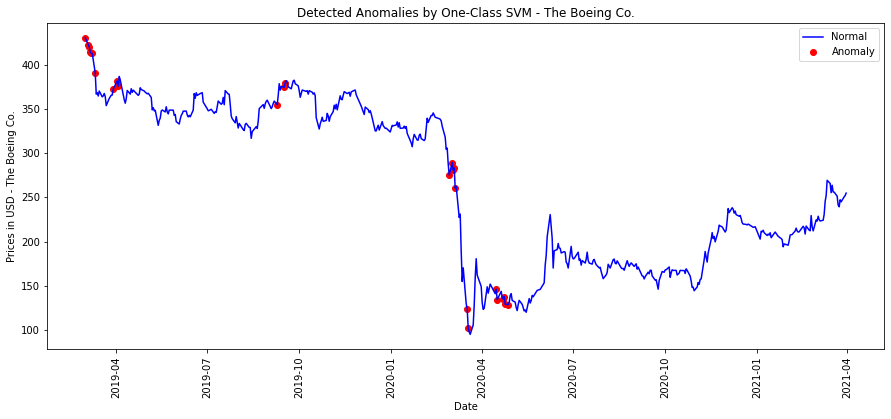

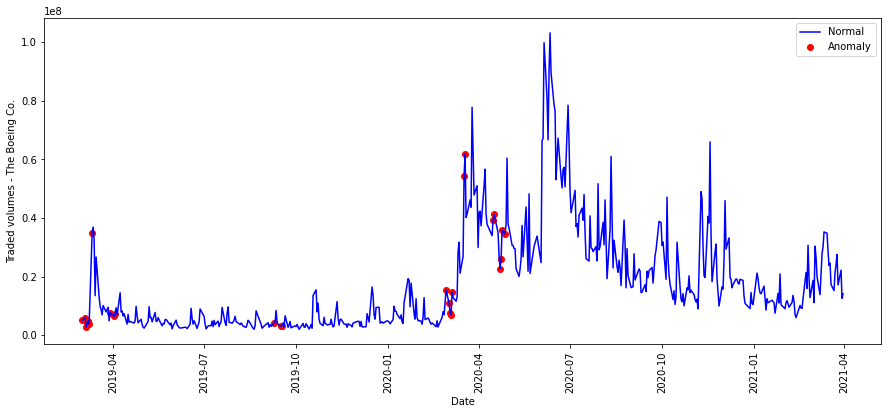

In [ ]:
# Plotting the data
fig, ax = plt.subplots(figsize=(15,6))
a = ba_historical_new.loc[ba_historical_new['anomaly_OneClassSVM'] == -1, ['Date', 'Close']] #anomaly

ax.plot(ba_historical_new['Date'], ba_historical_new['Close'], color='blue', label='Normal')
ax.scatter(a['Date'],a['Close'], color='red', label='Anomaly')
plt.legend()
plt.title('Detected Anomalies by One-Class SVM - The Boeing Co.')
plt.xlabel('Date')
plt.ylabel('Prices in USD - The Boeing Co.')
plt.xticks(rotation=90)
plt.show()


fig, ax = plt.subplots(figsize=(15,6))
a = ba_historical_new.loc[ba_historical_new['anomaly_OneClassSVM'] == -1, ['Date', 'Volume']] #anomaly

ax.plot(ba_historical_new['Date'], ba_historical_new['Volume'], color='blue', label='Normal')
ax.scatter(a['Date'],a['Volume'], color='red', label='Anomaly')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Traded volumes - The Boeing Co.')
plt.xticks(rotation=90)
plt.show()

### Gaussian distribution anomaly detection - The Boeing Co

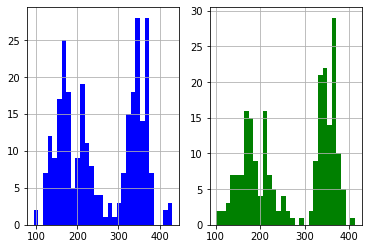

In [ ]:
ba_historical_new_c0 = ba_historical_new.loc[ba_historical_new['Binary_Close_&_Price'] == 0, 'Close']  # Bearish, market down
ba_historical_new_c1 = ba_historical_new.loc[ba_historical_new['Binary_Close_&_Price'] == 1, 'Close']  # Bullish, market up

fig, axs = plt.subplots(1,2)
ba_historical_new_c0.hist(ax=axs[0], bins=30, color='blue')
ba_historical_new_c1.hist(ax=axs[1], bins=30, color='green')

plt.show()

In [ ]:
envelope =  EllipticEnvelope(contamination = outliers_fraction)
X_train = ba_historical_new_c0.values.reshape(-1,1)
envelope.fit(X_train)
ba_historical_new_c0 = pd.DataFrame(ba_historical_new_c0)
ba_historical_new_c0['deviation'] = envelope.decision_function(X_train)
ba_historical_new_c0['anomaly'] = envelope.predict(X_train)

envelope =  EllipticEnvelope(contamination = outliers_fraction)
X_train = ba_historical_new_c1.values.reshape(-1,1)
envelope.fit(X_train)
ba_historical_new_c1 = pd.DataFrame(ba_historical_new_c1)
ba_historical_new_c1['deviation'] = envelope.decision_function(X_train)
ba_historical_new_c1['anomaly'] = envelope.predict(X_train)

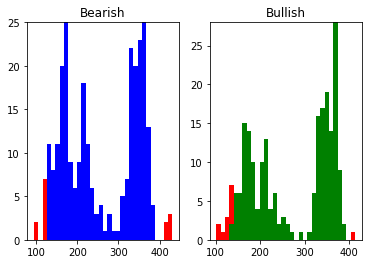

In [ ]:
# plot the price repartition by categories with anomalies

a0 = ba_historical_new_c0.loc[ba_historical_new_c0['anomaly'] == 1, 'Close']
b0 = ba_historical_new_c0.loc[ba_historical_new_c0['anomaly'] == -1, 'Close']

a2 = ba_historical_new_c1.loc[ba_historical_new_c1['anomaly'] == 1, 'Close']
b2 = ba_historical_new_c1.loc[ba_historical_new_c1['anomaly'] == -1, 'Close']

fig, axs = plt.subplots(1,2)
axs[0].hist([a0,b0], bins=32, stacked=True, color=['blue', 'red'])
axs[1].hist([a2,b2], bins=32, stacked=True, color=['green', 'red'])
axs[0].set_title("Bearish")
axs[1].set_title("Bullish")
plt.show()

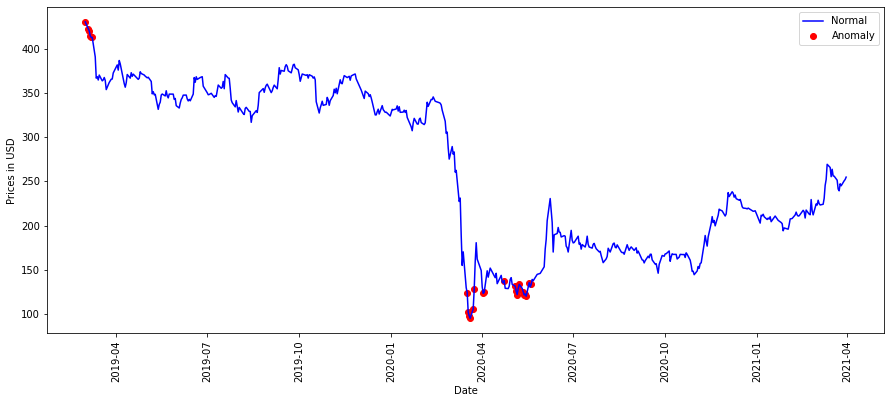

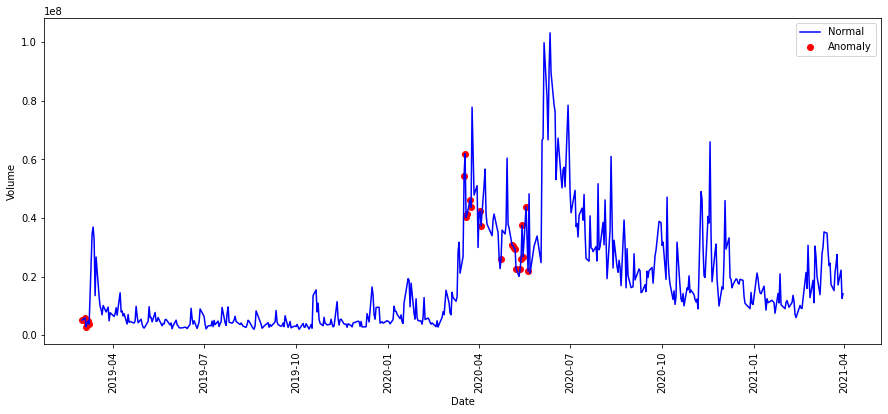

In [ ]:
# Plotting

ba_historical_new_c = pd.concat([ba_historical_new_c0, ba_historical_new_c1])
ba_historical_new['anomaly_GuassianD'] = ba_historical_new_c['anomaly']
# ba_historical_new['anomaly4'] = np.array(ba_historical_new['anomaly22'] == -1).astype(int)

#sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(15, 6))
a = ba_historical_new.loc[ba_historical_new['anomaly_GuassianD'] == -1, ('Date', 'Close')]    #anomaly
ax.plot(ba_historical_new['Date'], ba_historical_new['Close'], color='blue', label='Normal')
ax.scatter(a['Date'],a['Close'], color='red', label='Anomaly')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Prices in USD')
plt.xticks(rotation=90)
plt.show()


fig, ax = plt.subplots(figsize=(15, 6))
a = ba_historical_new.loc[ba_historical_new['anomaly_GuassianD'] == -1, ('Date', 'Volume')]    #anomaly
ax.plot(ba_historical_new['Date'], ba_historical_new['Volume'], color='blue', label='Normal')
ax.scatter(a['Date'],a['Volume'], color='red', label='Anomaly')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Volume')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Counting distinct number of anomalies in "traded Volumes"

ba_historical_new.loc[ba_historical_new['anomaly_GuassianD'] == -1,'anomaly_GuassianD'].agg(['count'])

count    26
Name: anomaly_GuassianD, dtype: int64

In [ ]:
ba_historical_new.loc[ba_historical_new['anomaly_GuassianD'].values == -1]

,Date,Open,Close,Volume,Bool_Close_&_Price,Binary_Close_&_Price,BA,anomaly_IsolationForest,anomaly_OneClassSVM,anomaly_GuassianD
0,2019-03-01,435.563760,430.299988,5124200.0,False,0,0.000000,-1.0,-1.0,-1
1,2019-03-04,432.839095,422.555725,5971000.0,False,0,0.137300,-1.0,-1.0,-1
2,2019-03-05,420.944364,420.045898,2844300.0,False,0,-0.180600,-1.0,-1.0,-1
3,2019-03-06,419.635754,414.518463,4159400.0,False,0,-0.106067,-1.0,-1.0,-1
4,2019-03-07,413.444215,412.662964,4893600.0,False,0,-0.098667,-1.0,-1.0,-1
5,2019-03-08,407.008586,412.643463,3794900.0,True,1,-0.129475,-1.0,-1.0,-1
263,2020-03-17,132.509995,124.139999,54492200.0,False,0,-0.129586,1.0,-1.0,-1
264,2020-03-18,99.860001,101.889999,61943200.0,True,1,-0.034233,1.0,-1.0,-1
265,2020-03-19,98.800003,97.709999,40210600.0,False,0,-0.042514,1.0,1.0,-1
266,2020-03-20,99.849998,95.010002,41370700.0,False,0,0.101775,1.0,1.0,-1


### Stock - Facebook Inc (FB)

In [ ]:
"""# Scrapping news Headlines of Facebook from year 2019 to 2021

mediumTitle1s = {}

url = 'https://www.investing.com/equities/facebook-inc-news/'
#print(url)

for page in range(1, 605):
  req = Request(url=url + str(page), headers={'user-agent': 'my-app'})
  #req = Request(url=url + str(page), headers={'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/89.0.4389.90 Safari/537.36'})
  response = urlopen(req)
  html = bs(response, features='html.parser')
  mediumTitle1 = html.find_all(lambda tag: tag.name == 'div' and tag.get('class') == ['mediumTitle1'])
  mediumTitle1s[page] = mediumTitle1  #key is 'page' in dictionary 'mediumTitels

#mediumTitle1s

data_news = []

for page, mediumTitle1 in mediumTitle1s.items():
  #print(page, mediumTitle1)

  for article in mediumTitle1:
    for article in article.find_all('article', {'class': "js-article-item articleItem "}):
      title = article.find('a', {'class': "title"}).text
    #for title in article.find_all('a', {'class': "title"}):
      #print(title)

      for article in article.find_all('span', {'class': "articleDetails"}):
        date = article.find('span', {'class': "date"}).text[3:15]
        #print(date)

      data_news.append([page, 'FB', date, title])"""

In [ ]:
"""# Saving extracted data to G-Drive

df_concatenated_fb = pd.DataFrame(data_news, columns=['page', 'FB', 'Date', 'title'])

fb_news_final_combo = df_concatenated_fb.to_csv('/content/drive/MyDrive/Colab Notebooks/Stock news_investment/FB/fb_news_1-605.csv')"""

## Reading extracted new Headline file from G-drive for Facebook stocks

In [ ]:
df_concatenated_fb = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Stock news_investment/FB/fb_news_1-605.csv')
df_concatenated_fb.info()

In [ ]:
df_concatenated_fb.isna().sum()

Unnamed: 0    0
page          0
FB            0
Date          0
title         0
dtype: int64

In [ ]:
# deleting Nan values and rechecking NaN in column 'date'

df_concatenated_fb = df_concatenated_fb.dropna()
df_concatenated_fb.isna().sum()

Unnamed: 0    0
page          0
FB            0
Date          0
title         0
dtype: int64

In [ ]:
# dropping unwanted column

df_concatenated_fb = df_concatenated_fb.drop(columns='Unnamed: 0')
df_concatenated_fb.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5703 entries, 0 to 5702
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   page    5703 non-null   int64 
 1   FB      5703 non-null   object
 2   Date    5703 non-null   object
 3   title   5703 non-null   object
dtypes: int64(1), object(3)
memory usage: 222.8+ KB


In [ ]:
# converting dtype of column 'Date'

df_concatenated_fb['Date'] = pd.to_datetime(df_concatenated_fb['Date'], dayfirst=True, errors='coerce')
df_concatenated_fb.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5703 entries, 0 to 5702
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   page    5703 non-null   int64         
 1   FB      5703 non-null   object        
 2   Date    5702 non-null   datetime64[ns]
 3   title   5703 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 222.8+ KB


In [ ]:
df_concatenated_fb.head()

,page,FB,Date,title
0,1,FB,NaT,"Myanmar junta cuts internet, protesters say th..."
1,1,FB,2021-04-01,Thai SEC says investors should have crypto tra...
2,1,FB,2021-04-01,U.S. Supreme Court backs Facebook in case abou...
3,1,FB,2021-04-01,Deliveroo IPO debacle leaves small investors w...
4,1,FB,2021-04-01,"Microsoft and Amazon lead S&P 500 to 4,000 points"


In [ ]:
df_concatenated_fb.isnull().sum()

page     0
FB       0
Date     1
title    0
dtype: int64

In [ ]:
df_concatenated_fb = df_concatenated_fb.dropna()
df_concatenated_fb.isnull().sum()

page     0
FB       0
Date     0
title    0
dtype: int64

In [ ]:
df_concatenated_fb = df_concatenated_fb.reset_index(drop=True)  # reset index here, by default index column will be reset in ascending order
df_concatenated_fb.head()

,page,FB,Date,title
0,1,FB,2021-04-01,Thai SEC says investors should have crypto tra...
1,1,FB,2021-04-01,U.S. Supreme Court backs Facebook in case abou...
2,1,FB,2021-04-01,Deliveroo IPO debacle leaves small investors w...
3,1,FB,2021-04-01,"Microsoft and Amazon lead S&P 500 to 4,000 points"
4,1,FB,2021-04-01,"On London rooftop, Royal Opera Chorus reunites..."


In [ ]:
# Saving combination of CLEANED news headlines of Facebook Inc in G-drive

fb_news_final_combo_cleaned = df_concatenated_fb.to_csv('/content/drive/MyDrive/Colab Notebooks/Stock news_investment/FB/fb_news_final_combo_cleaned.csv')

In [ ]:
df_concatenated_fb

In [ ]:
# Applying sentiment analyzer to FB news Headlines

vader = SentimentIntensityAnalyzer()

column_compound = lambda title: vader.polarity_scores(title)['compound']
#df_current_data_news['compound'] = df_current_data_news['title'].apply(column_compound)
df_concatenated_fb['compound_pol_fb'] = df_concatenated_fb['title'].apply(column_compound)
df_concatenated_fb

,page,FB,Date,title,compound_pol_fb
0,1,FB,2021-04-01,Thai SEC says investors should have crypto tra...,0.0000
1,1,FB,2021-04-01,U.S. Supreme Court backs Facebook in case abou...,0.3612
2,1,FB,2021-04-01,Deliveroo IPO debacle leaves small investors w...,-0.5423
3,1,FB,2021-04-01,"Microsoft and Amazon lead S&P 500 to 4,000 points",0.1779
4,1,FB,2021-04-01,"On London rooftop, Royal Opera Chorus reunites...",0.0000
...,...,...,...,...,...
5697,604,FB,2019-03-06,Zuckerberg says Facebook's future is going big...,0.0000
5698,604,FB,2019-03-06,U.S. Democrats unveil legislation to reinstate...,0.0000
5699,604,FB,2019-03-06,"EU states set to scrap digital tax plan, to wo...",0.0000
5700,604,FB,2019-03-06,Indian parliamentary panel asks Facebook to do...,-0.5209


In [ ]:
df_concatenated_fb = df_concatenated_fb.drop(columns='page')
df_concatenated_fb.head()

,FB,Date,title,compound_pol_fb
0,FB,2021-04-01,Thai SEC says investors should have crypto tra...,0.0000
1,FB,2021-04-01,U.S. Supreme Court backs Facebook in case abou...,0.3612
2,FB,2021-04-01,Deliveroo IPO debacle leaves small investors w...,-0.5423
3,FB,2021-04-01,"Microsoft and Amazon lead S&P 500 to 4,000 points",0.1779
4,FB,2021-04-01,"On London rooftop, Royal Opera Chorus reunites...",0.0000


In [ ]:
df_concatenated_fb = df_concatenated_fb.rename(columns={'FB': 'company'})

In [ ]:
df_concatenated_fb.head()

,company,Date,title,compound_pol_fb
0,FB,2021-04-01,Thai SEC says investors should have crypto tra...,0.0000
1,FB,2021-04-01,U.S. Supreme Court backs Facebook in case abou...,0.3612
2,FB,2021-04-01,Deliveroo IPO debacle leaves small investors w...,-0.5423
3,FB,2021-04-01,"Microsoft and Amazon lead S&P 500 to 4,000 points",0.1779
4,FB,2021-04-01,"On London rooftop, Royal Opera Chorus reunites...",0.0000


In [ ]:
df_concatenated_fb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5702 entries, 0 to 5701
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   company          5702 non-null   object        
 1   Date             5702 non-null   datetime64[ns]
 2   title            5702 non-null   object        
 3   compound_pol_fb  5702 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 178.3+ KB


In [ ]:
df_concatenated_fb.describe()

,compound_pol_fb
count,5702.000000
mean,-0.071570
std,0.353843
min,-0.952400
25%,-0.318200
50%,0.000000
75%,0.025800
max,0.880700


### Visualizing the data of Facebooks news sentiments

In [ ]:
#df_concatenated_fb['Date'] = pd.to_datetime(df_concatenated_fb.Date).dt.date  # parsing date using to_datetime

mean_df_concatenated_fb = df_concatenated_fb.groupby(['company', 'Date']).mean()  #grouping by date and company and then calculating the mean of the compound polarity of Facebook Inc
mean_df_concatenated_fb

In [ ]:
mean_df_concatenated_fb.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 714 entries, ('FB', Timestamp('2019-03-06 00:00:00')) to ('FB', Timestamp('2021-04-01 00:00:00'))
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   compound_pol_fb  714 non-null    float64
dtypes: float64(1)
memory usage: 13.4+ KB


In [ ]:
mean_df_concatenated_fb = mean_df_concatenated_fb.unstack()
mean_df_concatenated_fb = mean_df_concatenated_fb.xs('compound_pol_fb', axis="columns").transpose()  # transposing date and title on x and y axes respectively
mean_df_concatenated_fb

In [ ]:
mean_df_concatenated_fb = mean_df_concatenated_fb.reset_index('Date')
mean_df_concatenated_fb['Date'] = pd.to_datetime(mean_df_concatenated_ba['Date'])
#mean_df_concatenated_fb = mean_df_concatenated_fb.rename(columns={'date': 'Date'})
mean_df_concatenated_fb.info()

In [ ]:
fig = px.line(mean_df_concatenated_fb, x='Date', y='FB', title='<b>News sentiments polarity of Facebook from 2019 to 2021', labels={'FB': 'Compound Polarity rate (Facebook Inc.)'})
fig.update_layout(title_x=0.5)  # to center the title
fig.update_xaxes(rangeslider_visible=True, )
fig.show()

In [ ]:
"""# Plotting the data on Facebook's news sentiments

mean_df_concatenated_fb.plot(kind='bar', color=['blue'], figsize=(22,9), title='Compounded sentiment polarity of news Headlines of company-Facebook (FB) Stock from year 2019 to 2021', ylabel='Compound Polarity rate')
plt.show()"""

### Pulling historical stock prices of Facebook from Yahoo finance

In [ ]:
# Pulling historical stock prices

fb = yf.Ticker("FB")
fb_historical = fb.history(start="2019-03-01", end="2021-04-01", interval="1d")  # Daily stock price
fb_historical = fb_historical.reset_index('Date')

In [ ]:
fb_historical.info()

In [ ]:
fb_historical = fb_historical.drop(columns=['High', 'Low', 'Dividends', 'Stock Splits'])
fb_historical

In [ ]:
"""# Plotting Close price

#sns.set_style("darkgrid")
plt.figure(figsize=(15,6))
plt.plot(fb_historical['Date'], fb_historical['Close'], color='red', label='Close price')
plt.title("Stock prices of Facebook Inc from 2019 to 2021", fontsize = 16)
plt.xlabel('Dates', fontsize = 18)
plt.xticks(x = 'Date', rotation = 90)
#plt.margins(0.2)
plt.ylabel('Prices in USD', fontsize = 18)
plt.legend(fontsize=15)
#plt.fill_between(x, 'Close')
plt.show()


# Plotting Traded volume

#sns.set_style("darkgrid")
plt.figure(figsize=(15,6))
plt.plot(fb_historical['Date'], fb_historical['Volume'], label='Traded Volumes', color='blue')
plt.title("Traded volumes of Facebook stock from 2019 to 2021", fontsize = 16)
plt.xlabel('Dates', fontsize = 18)
plt.xticks(x = 'Date', rotation = 90)
#plt.margins(0.2)
plt.ylabel('Volume', fontsize = 18)
plt.legend(fontsize=15)
#plt.fill_between('Date', 'Close')
plt.show()"""

In [ ]:
# Plotting Close price

fig = px.line(fb_historical, x='Date', y='Close', title='<b>Stock prices of Facebook Inc. from 2019 to 2021</b>', labels={'Close': 'Stock prices in USD - Facebook'})
fig.update_layout(title_x=0.5)  # to center the title
fig.update_xaxes(rangeslider_visible=True, )
fig.show()

# Plotting Traded volume

fig = px.line(fb_historical, x='Date', y='Volume', title='<b>Traded volumes of Facebook stock from 2019 to 2021</b>', labels={'Volume': 'Traded volumes - Facebook'})
fig.update_layout(title_x=0.5)  # to center the title
fig.update_xaxes(rangeslider_visible=True, )
fig.show()

In [ ]:
#Checking where the Close price is greater then Open price

fb_historical['Bool_Close_&_Price'] = fb_historical['Close'].gt(fb_historical['Open'])
fb_historical

In [ ]:
# Changing Boolean values to Integer

fb_historical['Binary_Close_&_Price'] = fb_historical['Bool_Close_&_Price'].astype(int)
fb_historical

In [ ]:
mean_df_concatenated_fb.head()

company,Date,FB
0,2019-03-01,-0.167820
1,2019-03-02,-0.188700
2,2019-03-04,-0.205438
3,2019-03-05,-0.049250
4,2019-03-06,-0.345400


In [ ]:
# Concatenating Stock prices and Compound Polarity rate of Facebook Inc

fb_historical_new = fb_historical.merge(mean_df_concatenated_fb, how='outer')

fb_historical_new = fb_historical_new.sort_values(by=['Date'])
fb_historical_new

In [ ]:
fb_historical_new.isna().sum()

Date                     94
Open                    211
Close                   211
Volume                  211
Bool_Close_&_Price      211
Binary_Close_&_Price    211
FB                       23
dtype: int64

In [ ]:
# Deleting Null NaN values

fb_historical_new = fb_historical_new.dropna()

fb_historical_new.isna().sum()

In [ ]:
fb_historical_new.info()

In [ ]:
# Converting dtype of 'Binary_Close_&_Price' ton integer

fb_historical_new['Binary_Close_&_Price'] = fb_historical_new['Binary_Close_&_Price'].astype(int)

In [ ]:
fb_historical_new.info()

In [ ]:
fb_historical_new

In [ ]:
fb_historical_new = fb_historical_new.reset_index(drop=True)

In [ ]:
fb_historical_new.info()

In [ ]:
fb_historical_new.head()

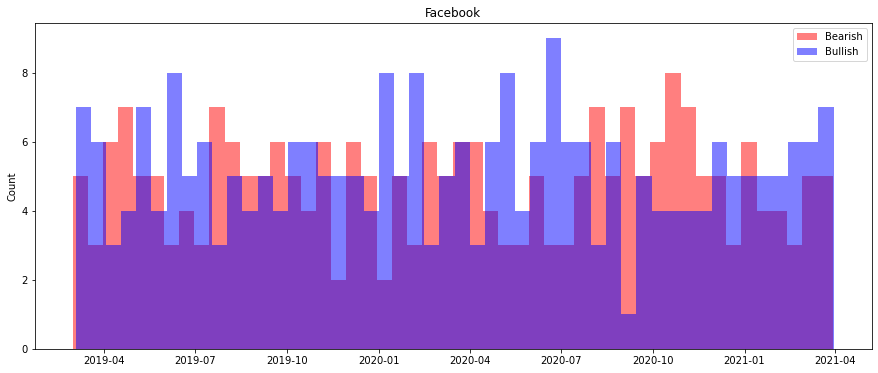

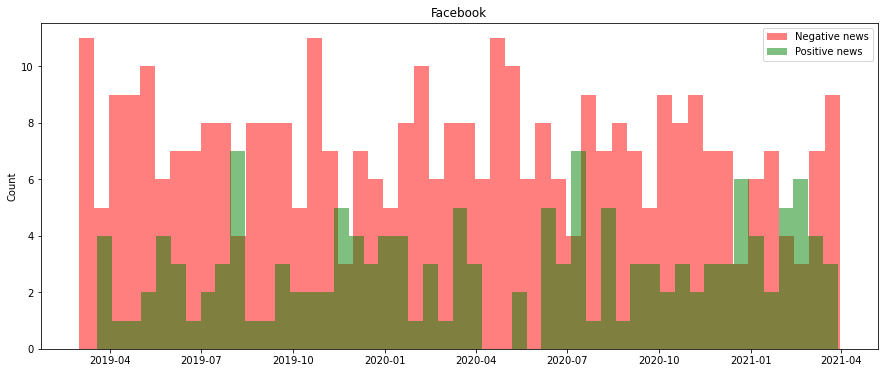

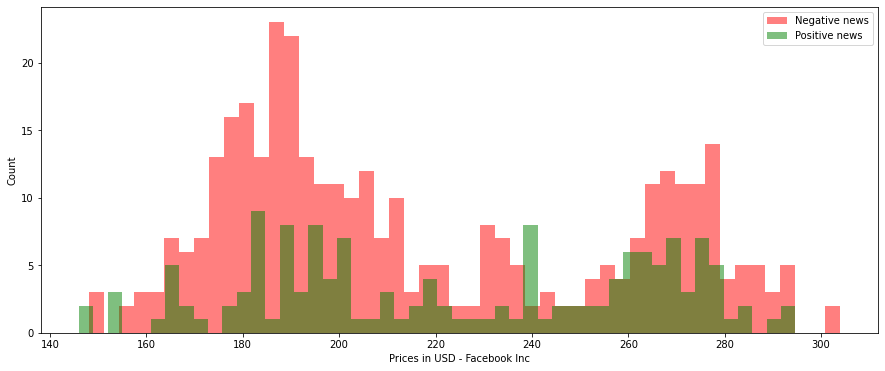

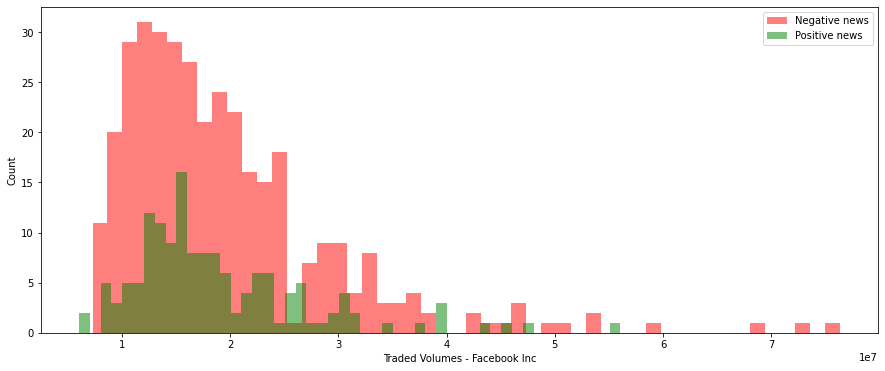

In [ ]:
#sns.set_style("darkgrid")
a = fb_historical_new.loc[fb_historical_new['Binary_Close_&_Price'] == 0, 'Date']  # When C.P < O.P, Bearish = market down
b = fb_historical_new.loc[fb_historical_new['Binary_Close_&_Price'] == 1, 'Date']  # When C.P > O.P, Bullish = market up
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Bearish', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Bullish', color='blue')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.title('Facebook')
#plt.xlabel('Date')
plt.ylabel('Count')
plt.show()

#sns.set_style("darkgrid")
a = fb_historical_new.loc[fb_historical_new['FB'] <= 0, 'Date']  # FB (compound polarity) < 0, means Negative News
b = fb_historical_new.loc[fb_historical_new['FB'] > 0, 'Date']  # FB (compound polarity) > 0, means Positive News
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Negative news', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Positive news', color='green')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.title('Facebook')
#plt.xlabel('Price - The Boeing Co')
plt.ylabel('Count')
plt.show()

a = fb_historical_new.loc[fb_historical_new['FB'] <= 0, 'Close']  # FB (compound polarity) < 0, means Negative News
b = fb_historical_new.loc[fb_historical_new['FB'] > 0, 'Close']  # FB (compound polarity) > 0, means Positive News
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Negative news', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Positive news', color='green')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.xlabel('Prices in USD - Facebook Inc')
plt.ylabel('Count')
plt.show()

#sns.set_style("darkgrid")
a = fb_historical_new.loc[fb_historical_new['FB'] <= 0, 'Volume']  # FB (compound polarity) < 0, means Negative News
b = fb_historical_new.loc[fb_historical_new['FB'] > 0, 'Volume']  # FB (compound polarity) > 0, means Positive News
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Negative news', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Positive news', color='green')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.xlabel('Traded Volumes - Facebook Inc')
plt.ylabel('Count')
plt.show()

In [ ]:
# Bullish v/s Bearish market in span of two years from 2019 to 2021

fb_historical_new['Binary_Close_&_Price'].value_counts()

1    261
0    242
Name: Binary_Close_&_Price, dtype: int64

### Anomaly Detection by Isolation Forest - Facebook Inc

# New Section

In [ ]:
# The important features for our analysis are "Close", Volume, "Compounded polarity" and "Binary_Close_&_Price"

data = fb_historical_new[['Close']]

sc = MinMaxScaler()
scaled = sc.fit_transform(data)  # scaling the data for fitting
data = pd.DataFrame(scaled)

# Building and training model with Isolation forest

outliers_fraction = 0.05  # Trying to detect 5% observations which may be different from the rest of our data.

model =  IsolationForest(contamination=outliers_fraction)
model.fit(data)

fb_historical_new['anomaly_IsolationForest'] = pd.Series(model.predict(data))

In [ ]:
fb_historical_new.head()

In [ ]:
fb_historical_new.info()

In [ ]:
# Counting distinct number of anomalies in "traded Volumes"

fb_historical_new.loc[fb_historical_new['anomaly_IsolationForest'] == -1,'anomaly_IsolationForest'].agg(['count'])

count    26
Name: anomaly_IsolationForest, dtype: int64

In [ ]:
anomaly_IF_FB = fb_historical_new.loc[fb_historical_new['anomaly_IsolationForest'].values == -1]
anomaly_IF_FB

In [ ]:
# Saving the results of anomalies by One-Class SVM in G-drive

anomaly_IF_FB_gdrive = anomaly_IF_FB.to_csv('/content/drive/MyDrive/Colab Notebooks/Results of Anamoly detection/Result_IsolationForest/Result_IF_FB.csv')

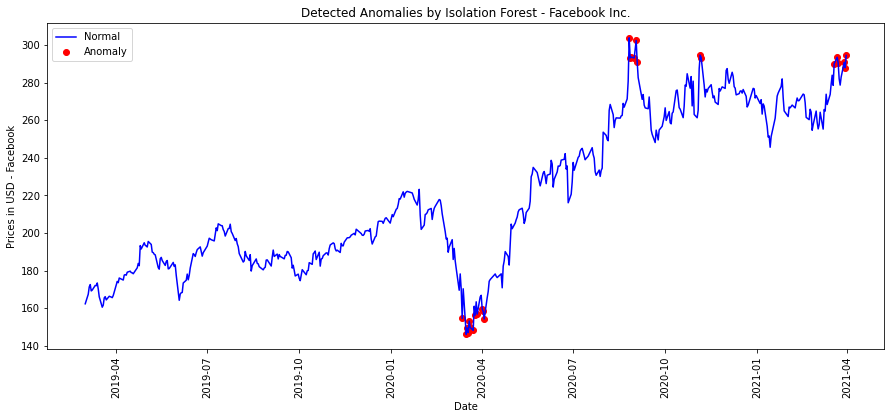

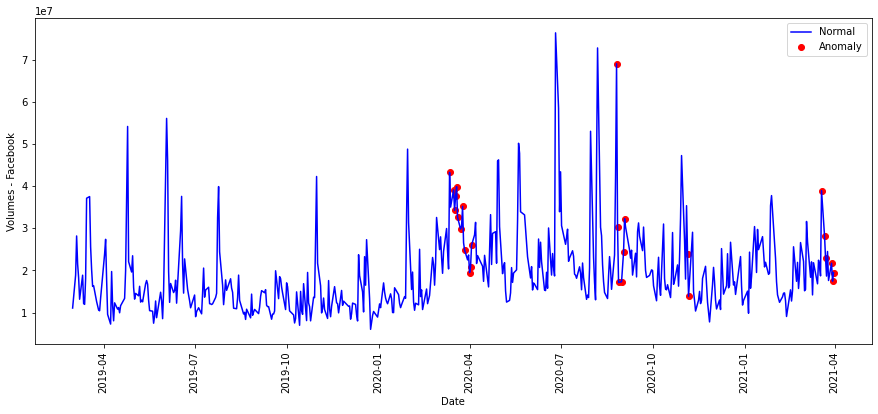

In [ ]:
# Plotting

fig, ax = plt.subplots(figsize=(15,6))

a = fb_historical_new.loc[fb_historical_new['anomaly_IsolationForest'] == -1, ['Date', 'Close']] #anomaly

#sns.set_style("darkgrid")
ax.plot(fb_historical_new['Date'], fb_historical_new['Close'], color='blue', label = 'Normal')
ax.scatter(a['Date'],a['Close'], color='red', label = 'Anomaly')
plt.legend()
plt.title('Detected Anomalies by Isolation Forest - Facebook Inc.')
plt.xlabel('Date')
plt.xticks(rotation=90)
plt.ylabel('Prices in USD - Facebook')
plt.show()

fig, ax = plt.subplots(figsize=(15,6))

a = fb_historical_new.loc[fb_historical_new['anomaly_IsolationForest'] == -1, ['Date', 'Volume']] #anomaly

#sns.set_style("darkgrid")
ax.plot(fb_historical_new['Date'], fb_historical_new['Volume'], color='blue', label = 'Normal')
ax.scatter(a['Date'],a['Volume'], color='red', label = 'Anomaly')
plt.legend()
plt.xlabel('Date')
plt.xticks(rotation=90)
plt.ylabel('Volumes - Facebook')
plt.show()

### One-Class SVM anomaly detection - Facebook stock

In [ ]:
data = fb_historical_new[['Close']]

sc = MinMaxScaler()
scaled = sc.fit_transform(data)
data = pd.DataFrame(scaled)

# Building and training One-class SVM model

model = OneClassSVM(nu=outliers_fraction, kernel="rbf", gamma=0.01)
model.fit(data)
fb_historical_new['anomaly_OneClassSVM'] = pd.Series(model.predict(data)) # -1 is anomaly and 1 is normal.

In [ ]:
fb_historical_new.head()

In [ ]:
# Counting distinct number of anomalies in "Facebook Stock Prices"

fb_historical_new.loc[fb_historical_new['anomaly_OneClassSVM'] == -1,'anomaly_OneClassSVM'].agg(['count'])

count    25
Name: anomaly_OneClassSVM, dtype: int64

In [ ]:
anomaly_OCSVM_FB = fb_historical_new.loc[fb_historical_new['anomaly_OneClassSVM'].values == -1]
anomaly_OCSVM_FB

In [ ]:
# Saving the results of anomalies by One-Class SVM in G-drive

anomaly_OCSVM_FB_gdrive = anomaly_OCSVM_FB.to_csv('/content/drive/MyDrive/Colab Notebooks/Results of Anamoly detection/Result_OneClassSVM/Result_OCSVM_FB.csv')

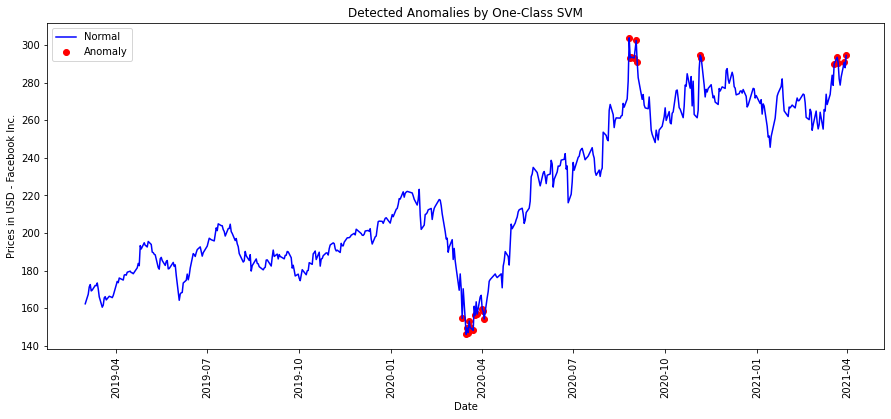

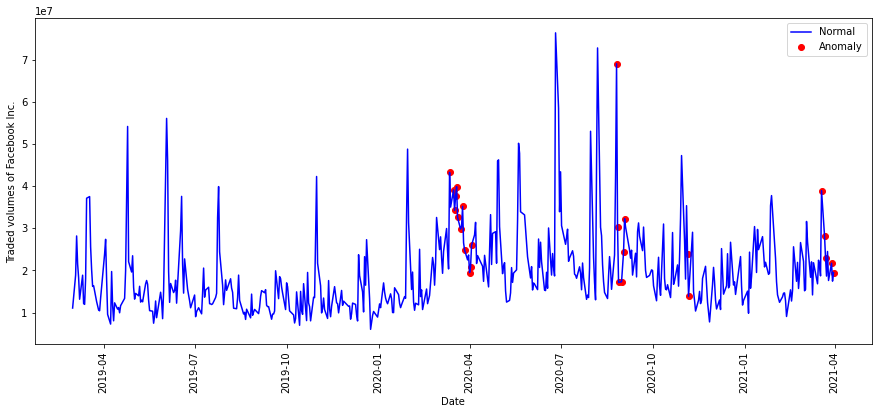

In [ ]:
# Plotting the data
fig, ax = plt.subplots(figsize=(15,6))
a = fb_historical_new.loc[fb_historical_new['anomaly_OneClassSVM'] == -1, ['Date', 'Close']] #anomaly

ax.plot(fb_historical_new['Date'], fb_historical_new['Close'], color='blue', label='Normal')
ax.scatter(a['Date'],a['Close'], color='red', label='Anomaly')
plt.legend()
plt.title('Detected Anomalies by One-Class SVM')
plt.xlabel('Date')
plt.ylabel('Prices in USD - Facebook Inc.')
plt.xticks(rotation=90)
plt.show()


fig, ax = plt.subplots(figsize=(15,6))
a = fb_historical_new.loc[fb_historical_new['anomaly_OneClassSVM'] == -1, ['Date', 'Volume']] #anomaly

ax.plot(fb_historical_new['Date'], fb_historical_new['Volume'], color='blue', label='Normal')
ax.scatter(a['Date'],a['Volume'], color='red', label='Anomaly')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Traded volumes of Facebook Inc.')
plt.xticks(rotation=90)
plt.show()

### Gaussian distribution anomaly detection - Facebook Inc

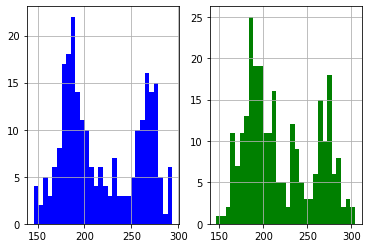

In [ ]:
fb_historical_new_c0 = fb_historical_new.loc[fb_historical_new['Binary_Close_&_Price'] == 0, 'Close']  # Bearish, market down
fb_historical_new_c1 = fb_historical_new.loc[fb_historical_new['Binary_Close_&_Price'] == 1, 'Close']  # Bullish, market up

fig, axs = plt.subplots(1,2)
fb_historical_new_c0.hist(ax=axs[0], bins=30, color='blue')
fb_historical_new_c1.hist(ax=axs[1], bins=30, color='green')

plt.show()

In [ ]:
envelope =  EllipticEnvelope(contamination = outliers_fraction)
X_train = fb_historical_new_c0.values.reshape(-1,1)
envelope.fit(X_train)
fb_historical_new_c0 = pd.DataFrame(fb_historical_new_c0)
fb_historical_new_c0['deviation'] = envelope.decision_function(X_train)
fb_historical_new_c0['anomaly'] = envelope.predict(X_train)

envelope =  EllipticEnvelope(contamination = outliers_fraction)
X_train = fb_historical_new_c1.values.reshape(-1,1)
envelope.fit(X_train)
fb_historical_new_c1 = pd.DataFrame(fb_historical_new_c1)
fb_historical_new_c1['deviation'] = envelope.decision_function(X_train)
fb_historical_new_c1['anomaly'] = envelope.predict(X_train)

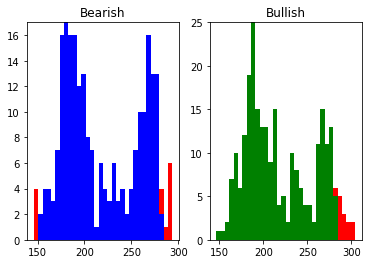

In [ ]:
# plot the price repartition by categories with anomalies

a0 = fb_historical_new_c0.loc[fb_historical_new_c0['anomaly'] == 1, 'Close']
b0 = fb_historical_new_c0.loc[fb_historical_new_c0['anomaly'] == -1, 'Close']

a2 = fb_historical_new_c1.loc[fb_historical_new_c1['anomaly'] == 1, 'Close']
b2 = fb_historical_new_c1.loc[fb_historical_new_c1['anomaly'] == -1, 'Close']

fig, axs = plt.subplots(1,2)
axs[0].hist([a0,b0], bins=32, stacked=True, color=['blue', 'red'])
axs[1].hist([a2,b2], bins=32, stacked=True, color=['green', 'red'])
axs[0].set_title("Bearish")
axs[1].set_title("Bullish")
plt.show()

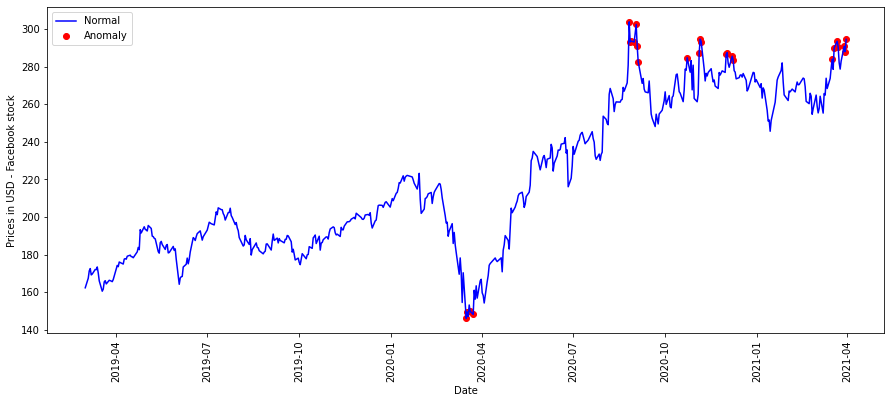

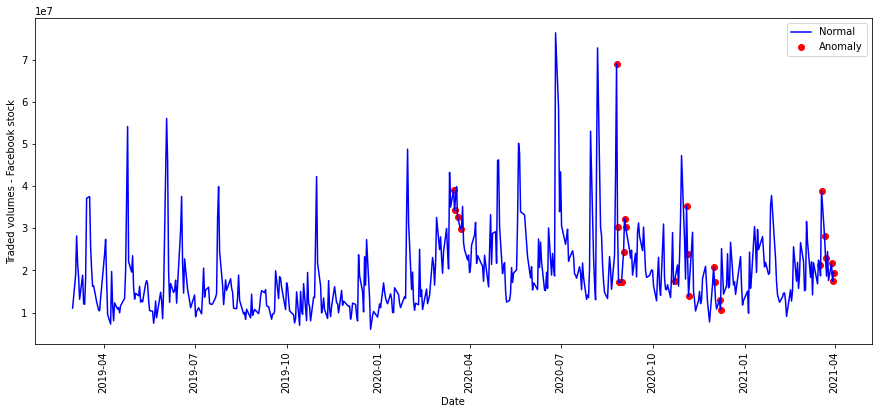

In [ ]:
# Plotting

fb_historical_new_c = pd.concat([fb_historical_new_c0, fb_historical_new_c1])
fb_historical_new['anomaly_GuassianD'] = fb_historical_new_c['anomaly']

#sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(15, 6))
a = fb_historical_new.loc[fb_historical_new['anomaly_GuassianD'] == -1, ('Date', 'Close')]    #anomaly
ax.plot(fb_historical_new['Date'], fb_historical_new['Close'], color='blue', label='Normal')
ax.scatter(a['Date'],a['Close'], color='red', label='Anomaly')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Prices in USD - Facebook stock')
plt.xticks(rotation=90)
plt.show()


fig, ax = plt.subplots(figsize=(15, 6))
a = fb_historical_new.loc[fb_historical_new['anomaly_GuassianD'] == -1, ('Date', 'Volume')]    #anomaly
ax.plot(fb_historical_new['Date'], fb_historical_new['Volume'], color='blue', label='Normal')
ax.scatter(a['Date'],a['Volume'], color='red', label='Anomaly')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Traded volumes - Facebook stock')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Counting distinct number of anomalies in "traded Volumes"

fb_historical_new.loc[fb_historical_new['anomaly_GuassianD'] == -1,'anomaly_GuassianD'].agg(['count'])

count    26
Name: anomaly_GuassianD, dtype: int64

In [ ]:
fb_historical_new.loc[fb_historical_new['anomaly_GuassianD'].values == -1]

,Date,Open,Close,Volume,Bool_Close_&_Price,Binary_Close_&_Price,FB,anomaly_IsolationForest,anomaly_OneClassSVM,anomaly_GuassianD
250,2020-03-16,152.320007,146.009995,39120400.0,False,0,0.004500,-1,-1,-1
251,2020-03-17,150.740005,149.419998,34255600.0,False,0,-0.095982,-1,-1,-1
254,2020-03-20,156.020004,149.729996,32568400.0,False,0,-0.064675,-1,-1,-1
255,2020-03-23,149.660004,148.100006,29830800.0,False,0,-0.230690,-1,-1,-1
360,2020-08-26,284.000000,303.910004,69015200.0,True,1,-0.183854,-1,-1,-1
361,2020-08-27,300.160004,293.220001,30301300.0,False,0,-0.226980,-1,-1,-1
362,2020-08-28,295.000000,293.660004,17157400.0,False,0,-0.381800,-1,-1,-1
363,2020-08-31,293.950012,293.200012,17345100.0,False,0,-0.125300,-1,-1,-1
364,2020-09-02,298.880005,302.500000,24341400.0,True,1,-0.073385,-1,-1,-1
365,2020-09-03,295.989990,291.119995,32294100.0,False,0,-0.064860,-1,-1,-1


### Stock - Tesla Inc (TSLA)

In [ ]:
"""# Scrapping news Headlines of Tesla from year 2019 to 2021

mediumTitle1s = {}

url = 'https://www.investing.com/equities/tesla-motors-news/'
#print(url)

for page in range(1, 343):
  req = Request(url=url + str(page), headers={'user-agent': 'my-app'})
  #req = Request(url=url + str(page), headers={'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/89.0.4389.90 Safari/537.36'})
  response = urlopen(req)
  html = bs(response, features='html.parser')
  mediumTitle1 = html.find_all(lambda tag: tag.name == 'div' and tag.get('class') == ['mediumTitle1'])
  mediumTitle1s[page] = mediumTitle1  #key is 'page' in dictionary 'mediumTitels

#mediumTitle1s

data_news = []

for page, mediumTitle1 in mediumTitle1s.items():
  #print(page, mediumTitle1)

  for article in mediumTitle1:
    for article in article.find_all('article', {'class': "js-article-item articleItem "}):
      title = article.find('a', {'class': "title"}).text
    #for title in article.find_all('a', {'class': "title"}):
      #print(title)

      for article in article.find_all('span', {'class': "articleDetails"}):
        date = article.find('span', {'class': "date"}).text[3:15]
        #print(date)

      data_news.append([page, 'TSLA', date, title])"""

In [ ]:
"""# Saving extracted data to G-Drive

df_concatenated_tsla = pd.DataFrame(data_news, columns=['page', 'TSLA', 'Date', 'title'])

tsla_news_final_combo = df_concatenated_tsla.to_csv('/content/drive/MyDrive/Colab Notebooks/Stock news_investment/TSLA/tsla_news_1-343.csv')"""

## Reading extracted new Headline file from G-drive for Tesla stocks

In [ ]:
df_concatenated_tsla = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Stock news_investment/TSLA/tsla_news_1-343.csv')
df_concatenated_tsla.info()

In [ ]:
df_concatenated_tsla.isna().sum()

Unnamed: 0    0
page          0
TSLA          0
Date          0
title         0
dtype: int64

In [ ]:
# deleting Nan values and rechecking NaN in column 'date'

df_concatenated_tsla = df_concatenated_tsla.dropna()
df_concatenated_tsla.isna().sum()

Unnamed: 0    0
page          0
TSLA          0
Date          0
title         0
dtype: int64

In [ ]:
# dropping unwanted column

df_concatenated_tsla = df_concatenated_tsla.drop(columns='Unnamed: 0')
df_concatenated_tsla.info()

In [ ]:
# converting dtype of column 'Date'

df_concatenated_tsla['Date'] = pd.to_datetime(df_concatenated_tsla['Date'], dayfirst=True, errors='coerce')
df_concatenated_tsla.info()

In [ ]:
df_concatenated_tsla.head()

In [ ]:
df_concatenated_tsla.isnull().sum()

page      0
TSLA      0
Date     11
title     0
dtype: int64

In [ ]:
df_concatenated_tsla = df_concatenated_tsla.dropna()
df_concatenated_tsla.isnull().sum()

In [ ]:
df_concatenated_tsla = df_concatenated_tsla.reset_index(drop=True)  # reset index here, by default index column will be reset in ascending order
df_concatenated_tsla.head()

In [ ]:
# Saving combination of CLEANED news headlines of Tesla Inc in G-drive

tsla_news_final_combo_cleaned = df_concatenated_tsla.to_csv('/content/drive/MyDrive/Colab Notebooks/Stock news_investment/TSLA/tsla_news_final_combo_cleaned.csv')

In [ ]:
df_concatenated_tsla

In [ ]:
# Applying sentiment analyzer to TSLA news Headlines

vader = SentimentIntensityAnalyzer()

column_compound = lambda title: vader.polarity_scores(title)['compound']
df_concatenated_tsla['compound_pol_tsla'] = df_concatenated_tsla['title'].apply(column_compound)
df_concatenated_tsla

In [ ]:
df_concatenated_tsla = df_concatenated_tsla.drop(columns='page')
df_concatenated_tsla.head()

In [ ]:
df_concatenated_tsla = df_concatenated_tsla.rename(columns={'TSLA': 'company'})

In [ ]:
df_concatenated_tsla.head()

In [ ]:
df_concatenated_tsla.info()

In [ ]:
df_concatenated_tsla.describe()

### Visualizing the data of Tesla stock news sentiments

In [ ]:
#df_concatenated_fb['Date'] = pd.to_datetime(df_concatenated_fb.Date).dt.date  # parsing date using to_datetime

mean_df_concatenated_tsla = df_concatenated_tsla.groupby(['company', 'Date']).mean()  #grouping by date and company and then calculating the mean of the compound polarity of Facebook Inc
mean_df_concatenated_tsla

In [ ]:
mean_df_concatenated_tsla = mean_df_concatenated_tsla.unstack()
mean_df_concatenated_tsla = mean_df_concatenated_tsla.xs('compound_pol_tsla', axis="columns").transpose()  # transposing date and title on x and y axes respectively
mean_df_concatenated_tsla

In [ ]:
mean_df_concatenated_tsla.info()

In [ ]:
mean_df_concatenated_tsla = mean_df_concatenated_tsla.reset_index('Date')
mean_df_concatenated_tsla['Date'] = pd.to_datetime(mean_df_concatenated_tsla['Date'])
#mean_df_concatenated_tsla = mean_df_concatenated_tsla.rename(columns={'date': 'Date'})
mean_df_concatenated_tsla.info()

In [ ]:
fig = px.bar(mean_df_concatenated_tsla, x='Date', y='TSLA', title='<b>News sentiments polarity of Tesla from 2019 to 2021', labels={'TSLA': 'Compound Polarity rate (Tesla)'})
fig.update_layout(title_x=0.5)  # to center the title
fig.update_xaxes(rangeslider_visible=True, )
fig.show()

## Pulling historical stock prices of Tesla from Yahoo finance

In [ ]:
# Pulling historical stock prices

tsla = yf.Ticker("TSLA")
tsla_historical = tsla.history(start="2019-03-01", end="2021-04-01", interval="1d")  # Daily stock price
tsla_historical = tsla_historical.reset_index('Date')

In [ ]:
tsla_historical.info()

In [ ]:
tsla_historical = tsla_historical.drop(columns=['High', 'Low', 'Dividends', 'Stock Splits'])
tsla_historical

In [ ]:
"""# Plotting Close price

#sns.set_style("darkgrid")
plt.figure(figsize=(15,6))
plt.plot(tsla_historical['Date'], tsla_historical['Close'], color='red', label='Close price')
plt.title("Stock prices of Tesla from 2019 to 2021", fontsize = 16)
plt.xlabel('Dates', fontsize = 18)
plt.xticks(x = 'Date', rotation = 90)
#plt.margins(0.2)
plt.ylabel('Prices in USD', fontsize = 18)
plt.legend(fontsize=15)
#plt.fill_between(x, 'Close')
plt.show()


# Plotting Traded volume

#sns.set_style("darkgrid")
plt.figure(figsize=(15,6))
plt.plot(tsla_historical['Date'], tsla_historical['Volume'], label='Traded Volumes', color='blue')
plt.title("Traded volumes of Tesla stock from 2019 to 2021", fontsize = 16)
plt.xlabel('Dates', fontsize = 18)
plt.xticks(x = 'Date', rotation = 90)
#plt.margins(0.2)
plt.ylabel('Volume', fontsize = 18)
plt.legend(fontsize=15)
#plt.fill_between('Date', 'Close')
plt.show()"""

In [ ]:
# Plotting Close price

fig = px.line(tsla_historical, x='Date', y='Close', title='<b>Stock prices of Tesla from 2019 to 2021</b>', labels={'Close': 'Stock prices in USD - Tesla'})
fig.update_layout(title_x=0.5)  # to center the title
fig.update_xaxes(rangeslider_visible=True, )
fig.show()

# Plotting Traded volume

fig = px.line(tsla_historical, x='Date', y='Volume', title='<b>Traded volumes of Tesla stock from 2019 to 2021</b>', labels={'Volume': 'Traded volumes - Tesla'})
fig.update_layout(title_x=0.5)  # to center the title
fig.update_xaxes(rangeslider_visible=True, )
fig.show()

In [ ]:
#Checking where the Close price is greater then Open price

tsla_historical['Bool_Close_&_Price'] = tsla_historical['Close'].gt(tsla_historical['Open'])
tsla_historical

In [ ]:
# Changing Boolean values to Integer

tsla_historical['Binary_Close_&_Price'] = tsla_historical['Bool_Close_&_Price'].astype(int)
tsla_historical

In [ ]:
tsla_historical.head()

,Date,Open,Close,Volume,Bool_Close_&_Price,Binary_Close_&_Price
0,2019-03-01,61.388000,58.958000,114557000,False,0
1,2019-03-04,59.624001,57.071999,85484000,False,0
2,2019-03-05,56.400002,55.307999,93823500,False,0
3,2019-03-06,55.296001,55.248001,51677500,False,0
4,2019-03-07,55.768002,55.318001,47212500,False,0


In [ ]:
# Concatenating Stock prices and Compound Polarity rate of Facebook Inc

tsla_historical_new = tsla_historical.merge(mean_df_concatenated_tsla, how='outer')

tsla_historical_new = tsla_historical_new.sort_values(by=['Date'])
tsla_historical_new

In [ ]:
fb_historical_new.isna().sum()

In [ ]:
# Deleting Null NaN values

tsla_historical_new = tsla_historical_new.dropna()

tsla_historical_new.isna().sum()

In [ ]:
tsla_historical_new.info()

In [ ]:
# Converting dtype of 'Binary_Close_&_Price' ton integer

tsla_historical_new['Binary_Close_&_Price'] = tsla_historical_new['Binary_Close_&_Price'].astype(int)

In [ ]:
tsla_historical_new.info()

In [ ]:
tsla_historical_new

In [ ]:
tsla_historical_new = tsla_historical_new.reset_index(drop=True)

In [ ]:
tsla_historical_new.info()

In [ ]:
tsla_historical_new

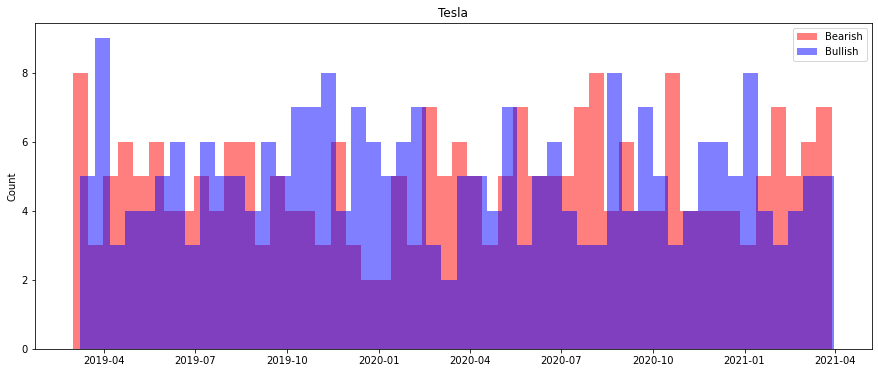

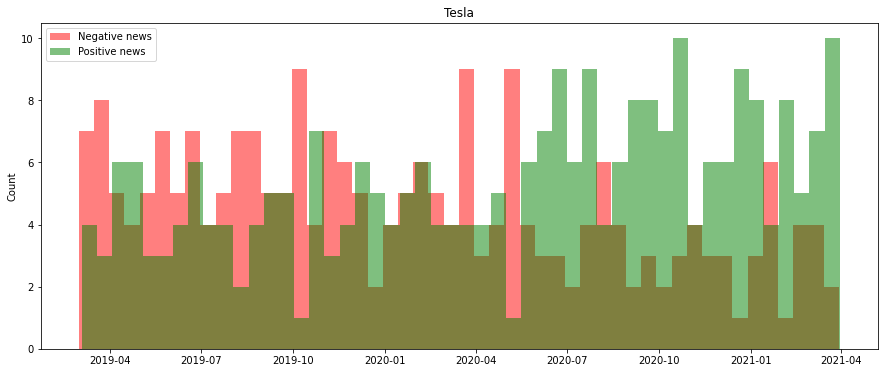

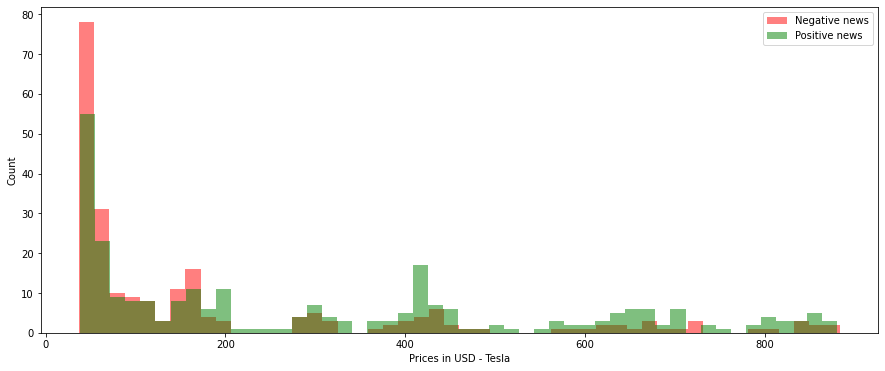

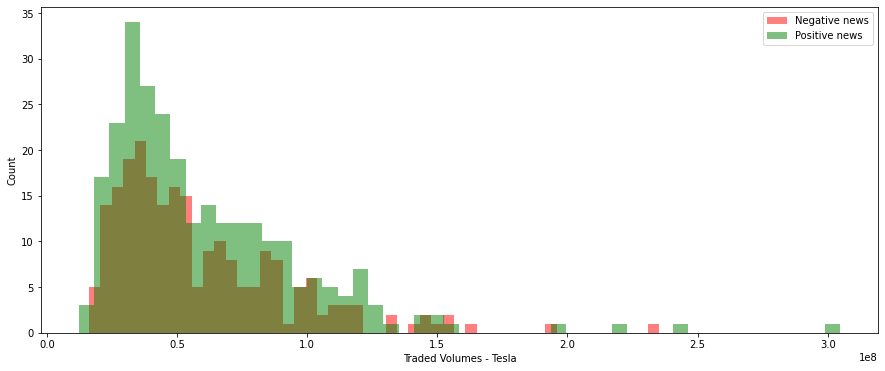

In [ ]:
#sns.set_style("darkgrid")
a = tsla_historical_new.loc[tsla_historical_new['Binary_Close_&_Price'] == 0, 'Date']  # When C.P < O.P, Bearish = market down
b = tsla_historical_new.loc[tsla_historical_new['Binary_Close_&_Price'] == 1, 'Date']  # When C.P > O.P, Bullish = market up
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Bearish', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Bullish', color='blue')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.title('Tesla')
#plt.xlabel('Date')
plt.ylabel('Count')
plt.show()

#sns.set_style("darkgrid")
a = tsla_historical_new.loc[tsla_historical_new['TSLA'] <= 0, 'Date']  # TSLA (compound polarity) < 0, means Negative News
b = tsla_historical_new.loc[tsla_historical_new['TSLA'] > 0, 'Date']  # TSLA (compound polarity) > 0, means Positive News
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Negative news', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Positive news', color='green')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.title('Tesla')
#plt.xlabel('Price - Tesla Stock')
plt.ylabel('Count')
plt.show()

a = tsla_historical_new.loc[tsla_historical_new['TSLA'] <= 0, 'Close']  # TSLA (compound polarity) < 0, means Negative News
b = tsla_historical_new.loc[tsla_historical_new['TSLA'] > 0, 'Close']  # TSLA (compound polarity) > 0, means Positive News
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Negative news', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Positive news', color='green')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.xlabel('Prices in USD - Tesla')
plt.ylabel('Count')
plt.show()

#sns.set_style("darkgrid")
a = tsla_historical_new.loc[tsla_historical_new['TSLA'] <= 0, 'Volume']  # TSLA (compound polarity) < 0, means Negative News
b = tsla_historical_new.loc[tsla_historical_new['TSLA'] > 0, 'Volume']  # TSLA (compound polarity) > 0, means Positive News
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Negative news', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Positive news', color='green')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.xlabel('Traded Volumes - Tesla')
plt.ylabel('Count')
plt.show()

In [ ]:
# Bullish v/s Bearish market in span of two years from 2019 to 2021

tsla_historical_new['Binary_Close_&_Price'].value_counts()

### Anomaly Detection by Isolation Forest - Tesla stock

In [ ]:
# The important features for our analysis are "Close", Volume, "Compounded polarity" and "Binary_Close_&_Price"

data = tsla_historical_new[['Close']]  # one feature

sc = MinMaxScaler()
scaled = sc.fit_transform(data)  # scaling the data for fitting
data = pd.DataFrame(scaled)

# Building and training model with Isolation forest

outliers_fraction = 0.05  # Trying to detect 5% observations which may be different from the rest of our data.

model =  IsolationForest(contamination=outliers_fraction)
model.fit(data)

tsla_historical_new['anomaly_IsolationForest'] = pd.Series(model.predict(data))

In [ ]:
tsla_historical_new.head()

In [ ]:
tsla_historical_new.info()

In [ ]:
# Counting distinct number of anomalies in "traded Volumes"

tsla_historical_new.loc[tsla_historical_new['anomaly_IsolationForest'] == -1,'anomaly_IsolationForest'].agg(['count'])

In [ ]:
anomaly_IF_TSLA = tsla_historical_new.loc[tsla_historical_new['anomaly_IsolationForest'].values == -1]
anomaly_IF_TSLA

In [ ]:
# Saving the results of anomalies by Isolation Forest in G-drive

anomaly_IF_TSLA_gdrive = anomaly_IF_TSLA.to_csv('/content/drive/MyDrive/Colab Notebooks/Results of Anamoly detection/Result_IsolationForest/Result_IF_TSLA.csv')

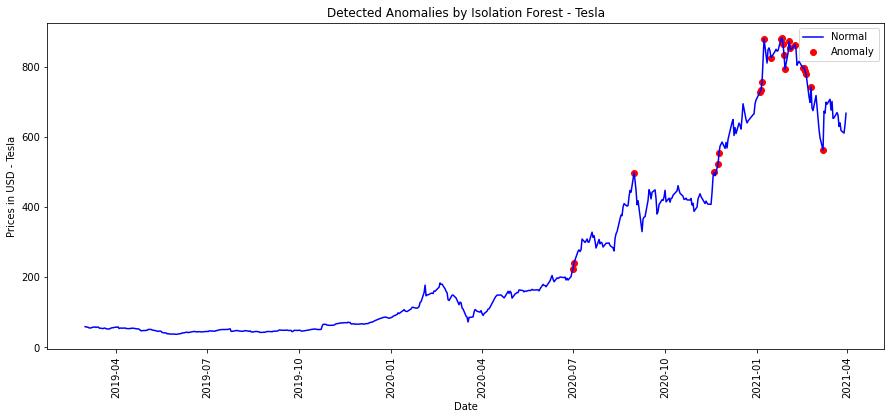

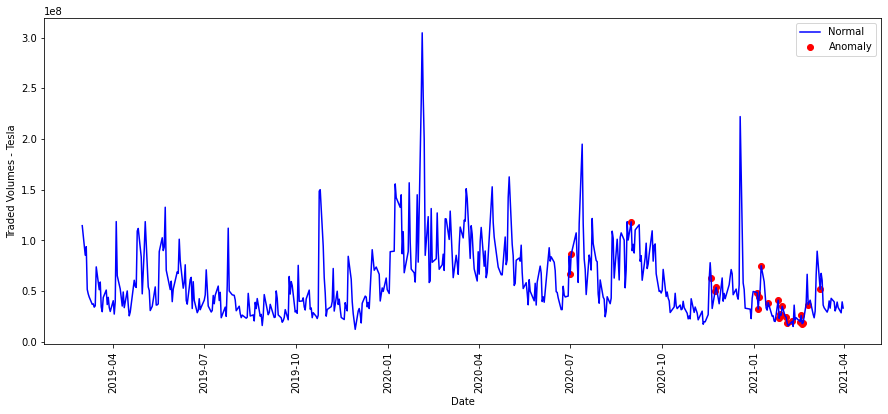

In [ ]:
# Plotting

fig, ax = plt.subplots(figsize=(15,6))

a = tsla_historical_new.loc[tsla_historical_new['anomaly_IsolationForest'] == -1, ['Date', 'Close']] #anomaly

#sns.set_style("darkgrid")
ax.plot(tsla_historical_new['Date'], tsla_historical_new['Close'], color='blue', label = 'Normal')
ax.scatter(a['Date'],a['Close'], color='red', label = 'Anomaly')
plt.legend()
plt.title('Detected Anomalies by Isolation Forest - Tesla')
plt.xlabel('Date')
plt.xticks(rotation=90)
plt.ylabel('Prices in USD - Tesla')
plt.show()

fig, ax = plt.subplots(figsize=(15,6))

a = tsla_historical_new.loc[tsla_historical_new['anomaly_IsolationForest'] == -1, ['Date', 'Volume']] #anomaly

#sns.set_style("darkgrid")
ax.plot(tsla_historical_new['Date'], tsla_historical_new['Volume'], color='blue', label = 'Normal')
ax.scatter(a['Date'],a['Volume'], color='red', label = 'Anomaly')
plt.legend()
plt.xlabel('Date')
plt.xticks(rotation=90)
plt.ylabel('Traded Volumes - Tesla')
plt.show()

### One-Class SVM anomaly detection - Tesla stock

In [ ]:
data = tsla_historical_new[['Close']]

sc = MinMaxScaler()
scaled = sc.fit_transform(data)
data = pd.DataFrame(scaled)

# Building and training One-class SVM model

model = OneClassSVM(nu=outliers_fraction, kernel="rbf", gamma=0.01)  # Since one feature is considered in our experiment, gamma equal to 1/100.
model.fit(data)
tsla_historical_new['anomaly_OneClassSVM'] = pd.Series(model.predict(data)) # -1 is anomaly and 1 is normal.

In [ ]:
tsla_historical_new.head()

In [ ]:
# Counting distinct number of anomalies in "Tesla Stock Prices"

tsla_historical_new.loc[tsla_historical_new['anomaly_OneClassSVM'] == -1,'anomaly_OneClassSVM'].agg(['count'])

In [ ]:
anomaly_OCSVM_TSLA = tsla_historical_new.loc[tsla_historical_new['anomaly_OneClassSVM'].values == -1]
anomaly_OCSVM_TSLA

In [ ]:
# Saving the results of anomalies by One-Class SVM in G-drive

anomaly_OCSVM_TSLA_gdrive = anomaly_OCSVM_TSLA.to_csv('/content/drive/MyDrive/Colab Notebooks/Results of Anamoly detection/Result_OneClassSVM/Result_OCSVM_TSLA.csv')

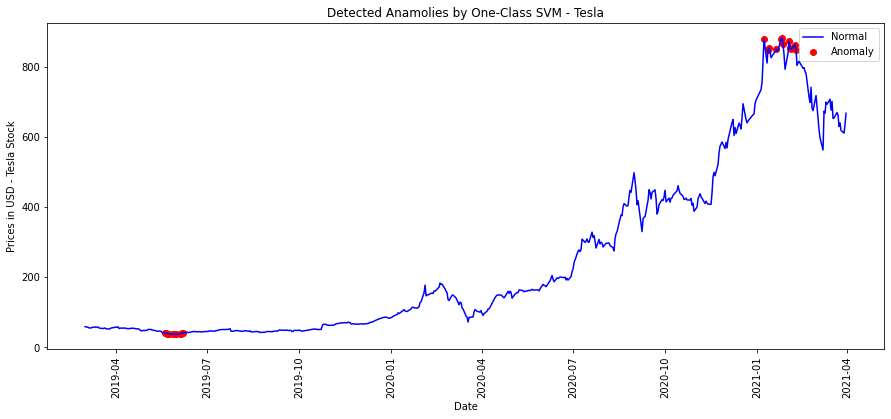

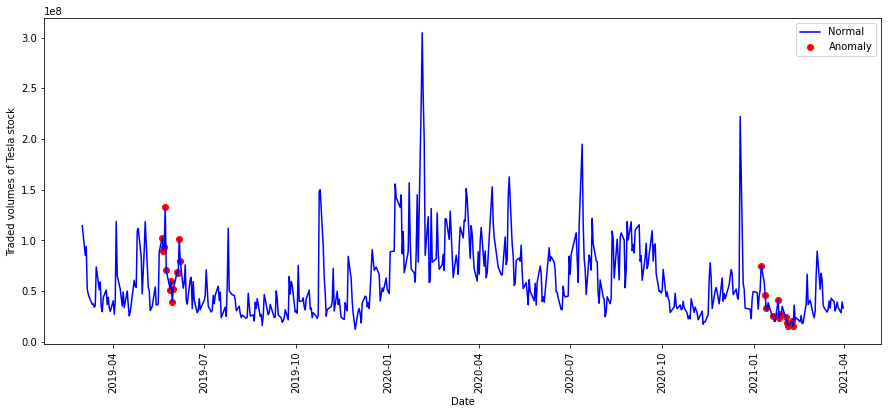

In [ ]:
# Plotting the data
fig, ax = plt.subplots(figsize=(15,6))
a = tsla_historical_new.loc[tsla_historical_new['anomaly_OneClassSVM'] == -1, ['Date', 'Close']] #anomaly

ax.plot(tsla_historical_new['Date'], tsla_historical_new['Close'], color='blue', label='Normal')
ax.scatter(a['Date'],a['Close'], color='red', label='Anomaly')
plt.legend()
plt.title('Detected Anamolies by One-Class SVM - Tesla')
plt.xlabel('Date')
plt.ylabel('Prices in USD - Tesla Stock')
plt.xticks(rotation=90)
plt.show()


fig, ax = plt.subplots(figsize=(15,6))
a = tsla_historical_new.loc[tsla_historical_new['anomaly_OneClassSVM'] == -1, ['Date', 'Volume']] #anomaly

ax.plot(tsla_historical_new['Date'], tsla_historical_new['Volume'], color='blue', label='Normal')
ax.scatter(a['Date'],a['Volume'], color='red', label='Anomaly')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Traded volumes of Tesla stock')
plt.xticks(rotation=90)
plt.show()

### Stock Amazon.com Inc (AMZN)

In [ ]:
"""# Scrapping news Headlines of Amazon from year 2019 to 2021

mediumTitle1s = {}

url = 'https://www.investing.com/equities/amazon-com-inc-news/'
#print(url)

for page in range(3, 465):
  req = Request(url=url + str(page), headers={'user-agent': 'my-app'})
  #req = Request(url=url + str(page), headers={'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/89.0.4389.90 Safari/537.36'})
  response = urlopen(req)
  html = bs(response, features='html.parser')
  mediumTitle1 = html.find_all(lambda tag: tag.name == 'div' and tag.get('class') == ['mediumTitle1'])
  mediumTitle1s[page] = mediumTitle1  #key is 'page' in dictionary 'mediumTitels

#mediumTitle1s

data_news = []

for page, mediumTitle1 in mediumTitle1s.items():
  #print(page, mediumTitle1)

  for article in mediumTitle1:
    for article in article.find_all('article', {'class': "js-article-item articleItem "}):
      title = article.find('a', {'class': "title"}).text
    #for title in article.find_all('a', {'class': "title"}):
      #print(title)

      for article in article.find_all('span', {'class': "articleDetails"}):
        date = article.find('span', {'class': "date"}).text[3:15]
        #print(date)

      data_news.append([page, 'AMZN', date, title])"""

In [ ]:
"""# Saving extracted data to G-Drive

df_concatenated_amzn = pd.DataFrame(data_news, columns=['page', 'AMZN', 'Date', 'title'])

amzn_news_final_combo = df_concatenated_amzn.to_csv('/content/drive/MyDrive/Colab Notebooks/Stock news_investment/AMZN/amzn_news_3-465.csv')"""

## Reading extracted new Headline file from G-drive for Amazon stocks

In [ ]:
df_concatenated_amzn = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Stock news_investment/AMZN/amzn_news_3-465.csv')
df_concatenated_amzn.info()

In [ ]:
df_concatenated_amzn.isna().sum()

In [ ]:
# deleting Nan values and rechecking NaN in column 'date'

df_concatenated_amzn = df_concatenated_amzn.dropna()
df_concatenated_amzn.isna().sum()

In [ ]:
# dropping unwanted column

df_concatenated_amzn = df_concatenated_amzn.drop(columns='Unnamed: 0')
df_concatenated_amzn.info()

In [ ]:
# converting dtype of column 'Date'

df_concatenated_amzn['Date'] = pd.to_datetime(df_concatenated_amzn['Date'], dayfirst=True, errors='coerce')
df_concatenated_amzn.info()

In [ ]:
df_concatenated_amzn.head()

In [ ]:
df_concatenated_amzn.isnull().sum()

In [ ]:
df_concatenated_amzn = df_concatenated_amzn.dropna()
df_concatenated_amzn.isnull().sum()

In [ ]:
df_concatenated_amzn = df_concatenated_amzn.reset_index(drop=True)  # reset index here, by default index column will be reset in ascending order
df_concatenated_amzn.head()

In [ ]:
# Saving combination of CLEANED news headlines of Tesla Inc in G-drive

amzn_news_final_combo_cleaned = df_concatenated_amzn.to_csv('/content/drive/MyDrive/Colab Notebooks/Stock news_investment/AMZN/amzn_news_final_combo_cleaned.csv')

In [ ]:
df_concatenated_amzn

In [ ]:
# Applying sentiment analyzer to TSLA news Headlines

vader = SentimentIntensityAnalyzer()

column_compound = lambda title: vader.polarity_scores(title)['compound']
df_concatenated_amzn['compound_pol_amzn'] = df_concatenated_amzn['title'].apply(column_compound)
df_concatenated_amzn

In [ ]:
df_concatenated_amzn = df_concatenated_amzn.drop(columns='page')
df_concatenated_amzn.head()

In [ ]:
df_concatenated_amzn = df_concatenated_amzn.rename(columns={'AMZN': 'company'})

In [ ]:
df_concatenated_amzn.head()

In [ ]:
df_concatenated_amzn.info()

In [ ]:
df_concatenated_amzn.describe()

### Visualizing the data of Amazon stock news sentiments

In [ ]:
#df_concatenated_fb['Date'] = pd.to_datetime(df_concatenated_fb.Date).dt.date  # parsing date using to_datetime

mean_df_concatenated_amzn = df_concatenated_amzn.groupby(['company', 'Date']).mean()  #grouping by date and company and then calculating the mean of the compound polarity of Facebook Inc
mean_df_concatenated_amzn

In [ ]:
mean_df_concatenated_amzn = mean_df_concatenated_amzn.unstack()
mean_df_concatenated_amzn = mean_df_concatenated_amzn.xs('compound_pol_amzn', axis="columns").transpose()  # transposing date and title on x and y axes respectively
mean_df_concatenated_amzn

In [ ]:
mean_df_concatenated_amzn.info()

In [ ]:
mean_df_concatenated_amzn = mean_df_concatenated_amzn.reset_index('Date')
mean_df_concatenated_amzn['Date'] = pd.to_datetime(mean_df_concatenated_amzn['Date'])
mean_df_concatenated_amzn.info()

In [ ]:
fig = px.bar(mean_df_concatenated_amzn, x='Date', y='AMZN', title='<b>News sentiments polarity of Amazon.com Inc. from 2019 to 2021', labels={'AMZN': 'Compound Polarity rate (Amazon.com Inc.)'})
fig.update_layout(title_x=0.5)  # to center the title
fig.update_xaxes(rangeslider_visible=True, )
fig.show()

### Pulling historical stock prices of Amazon from Yahoo finance

In [ ]:
# Pulling historical stock prices

amzn = yf.Ticker("AMZN")
amzn_historical = amzn.history(start="2019-03-01", end="2021-04-01", interval="1d")  # Daily stock price
amzn_historical = amzn_historical.reset_index('Date')

In [ ]:
amzn_historical.info()

In [ ]:
amzn_historical = amzn_historical.drop(columns=['High', 'Low', 'Dividends', 'Stock Splits'])
amzn_historical

In [ ]:
"""# Plotting Close price

#sns.set_style("darkgrid")
plt.figure(figsize=(15,6))
plt.plot(amzn_historical['Date'], amzn_historical['Close'], color='red', label='Close price')
plt.title("Stock prices of Amazon from 2019 to 2021", fontsize = 16)
plt.xlabel('Dates', fontsize = 18)
plt.xticks(x = 'Date', rotation = 90)
#plt.margins(0.2)
plt.ylabel('Prices in USD', fontsize = 18)
plt.legend(fontsize=15)
#plt.fill_between(x, 'Close')
plt.show()


# Plotting Traded volume

#sns.set_style("darkgrid")
plt.figure(figsize=(15,6))
plt.plot(amzn_historical['Date'], amzn_historical['Volume'], label='Traded Volumes', color='blue')
plt.title("Traded volumes of Amazon stock from 2019 to 2021", fontsize = 16)
plt.xlabel('Dates', fontsize = 18)
plt.xticks(x = 'Date', rotation = 90)
#plt.margins(0.2)
plt.ylabel('Volume', fontsize = 18)
plt.legend(fontsize=15)
#plt.fill_between('Date', 'Close')
plt.show()"""

In [ ]:
# Plotting Close price

fig = px.line(amzn_historical, x='Date', y='Close', title='<b>Stock prices of Amazon.com Inc. from 2019 to 2021</b>', labels={'Close': 'Stock prices in USD - Amazon'})
fig.update_layout(title_x=0.5)  # to center the title
fig.update_xaxes(rangeslider_visible=True, )
fig.show()

# Plotting Traded volume

fig = px.line(amzn_historical, x='Date', y='Volume', title='<b>Traded volumes of Amazon stock from 2019 to 2021</b>', labels={'Volume': 'Traded volumes - Amazon stock'})
fig.update_layout(title_x=0.5)  # to center the title
fig.update_xaxes(rangeslider_visible=True, )
fig.show()

In [ ]:
#Checking where the Close price is greater then Open price

amzn_historical['Bool_Close_&_Price'] = amzn_historical['Close'].gt(amzn_historical['Open'])
amzn_historical

In [ ]:
# Changing Boolean values to Integer

amzn_historical['Binary_Close_&_Price'] = amzn_historical['Bool_Close_&_Price'].astype(int)
amzn_historical

In [ ]:
amzn_historical.head()

In [ ]:
# Concatenating Stock prices and Compound Polarity rate of Facebook Inc

amzn_historical_new = amzn_historical.merge(mean_df_concatenated_amzn, how='outer')

amzn_historical_new = amzn_historical_new.sort_values(by=['Date'])
amzn_historical_new

In [ ]:
amzn_historical_new.isna().sum()

In [ ]:
# Deleting Null NaN values

amzn_historical_new = amzn_historical_new.dropna()

amzn_historical_new.isna().sum()

In [ ]:
amzn_historical_new.info()

In [ ]:
# Converting dtype of 'Binary_Close_&_Price' ton integer

amzn_historical_new['Binary_Close_&_Price'] = amzn_historical_new['Binary_Close_&_Price'].astype(int)

In [ ]:
amzn_historical_new.info()

In [ ]:
amzn_historical_new

In [ ]:
amzn_historical_new = amzn_historical_new.reset_index(drop=True)

In [ ]:
amzn_historical_new.info()

In [ ]:
amzn_historical_new

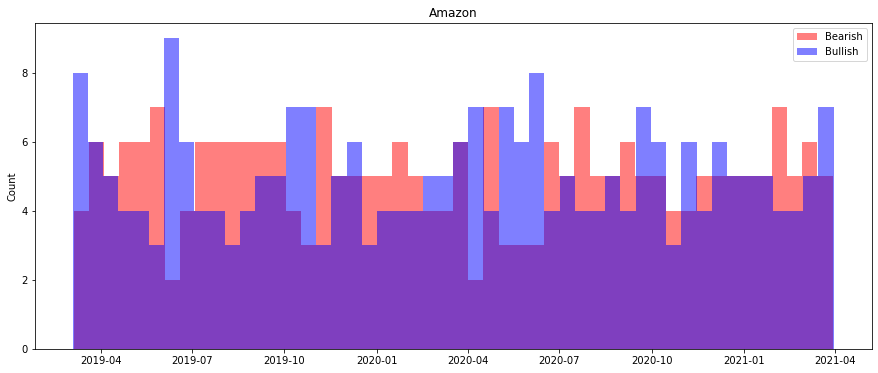

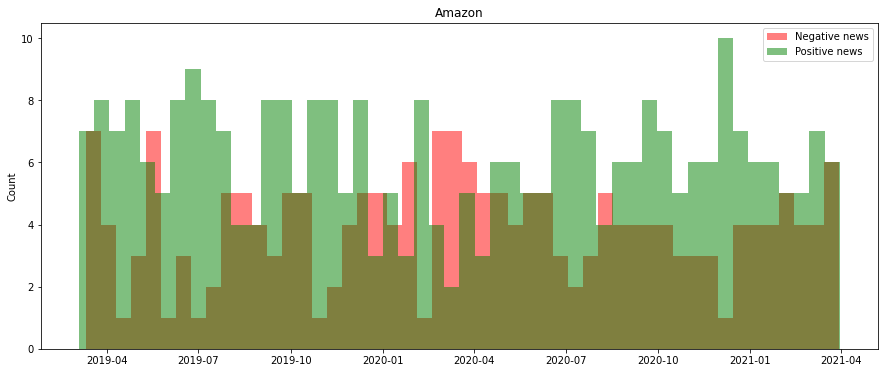

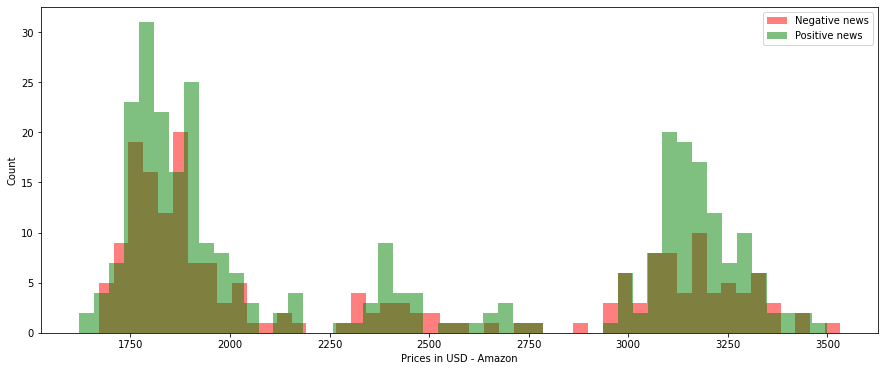

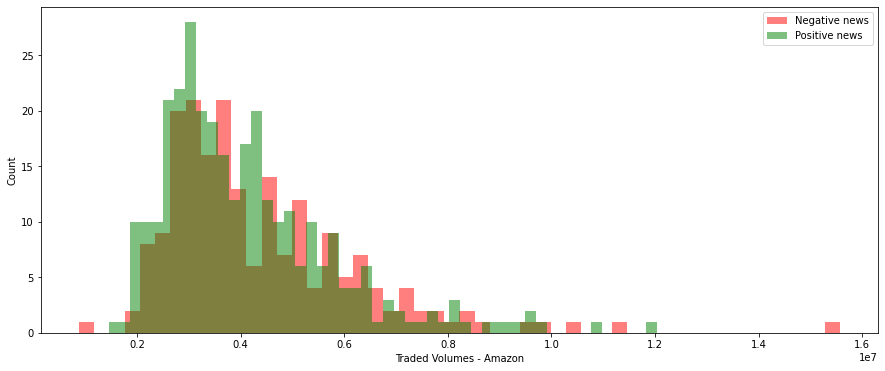

In [ ]:
#sns.set_style("darkgrid")
a = amzn_historical_new.loc[amzn_historical_new['Binary_Close_&_Price'] == 0, 'Date']  # When C.P < O.P, Bearish = market down
b = amzn_historical_new.loc[amzn_historical_new['Binary_Close_&_Price'] == 1, 'Date']  # When C.P > O.P, Bullish = market up
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Bearish', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Bullish', color='blue')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.title('Amazon')
#plt.xlabel('Date')
plt.ylabel('Count')
plt.show()

#sns.set_style("darkgrid")
a = amzn_historical_new.loc[amzn_historical_new['AMZN'] <= 0, 'Date']  # AMZN (compound polarity) < 0, means Negative News
b = amzn_historical_new.loc[amzn_historical_new['AMZN'] > 0, 'Date']  # AMZN (compound polarity) > 0, means Positive News
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Negative news', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Positive news', color='green')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.title('Amazon')
#plt.xlabel('Price - Tesla Stock')
plt.ylabel('Count')
plt.show()

a = amzn_historical_new.loc[amzn_historical_new['AMZN'] <= 0, 'Close']  # AMZN (compound polarity) < 0, means Negative News
b = amzn_historical_new.loc[amzn_historical_new['AMZN'] > 0, 'Close']  # AMZN (compound polarity) > 0, means Positive News
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Negative news', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Positive news', color='green')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.xlabel('Prices in USD - Amazon')
plt.ylabel('Count')
plt.show()

#sns.set_style("darkgrid")
a = amzn_historical_new.loc[amzn_historical_new['AMZN'] <= 0, 'Volume']  # AMZN (compound polarity) < 0, means Negative News
b = amzn_historical_new.loc[amzn_historical_new['AMZN'] > 0, 'Volume']  # AMZN (compound polarity) > 0, means Positive News
plt.figure(figsize=(15, 6))
plt.hist(a, bins = 50, alpha=0.5, label='Negative news', color='red')
plt.hist(b, bins = 50, alpha=0.5, label='Positive news', color='green')
#plt.legend(loc='upper right')
plt.legend(loc='best')
plt.xlabel('Traded Volumes - Amazon')
plt.ylabel('Count')
plt.show()

In [ ]:
# Bullish v/s Bearish market in span of two years from 2019 to 2021

amzn_historical_new['Binary_Close_&_Price'].value_counts()

### Anomaly Detection by Isolation Forest - Amazon stock

In [ ]:
# The important features for our analysis are "Close", Volume, "Compounded polarity" and "Binary_Close_&_Price"

data = amzn_historical_new[['Close']]

sc = MinMaxScaler()
scaled = sc.fit_transform(data)  # scaling the data for fitting
data = pd.DataFrame(scaled)

# Building and training model with Isolation forest

outliers_fraction = 0.05  # Trying to detect 5% observations which may be different from the rest of our data.

model =  IsolationForest(contamination=outliers_fraction)
model.fit(data)

amzn_historical_new['anomaly_IsolationForest'] = pd.Series(model.predict(data))

In [ ]:
amzn_historical_new.head()

In [ ]:
amzn_historical_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     507 non-null    datetime64[ns]
 1   Open                     507 non-null    float64       
 2   Close                    507 non-null    float64       
 3   Volume                   507 non-null    float64       
 4   Bool_Close_&_Price       507 non-null    object        
 5   Binary_Close_&_Price     507 non-null    int64         
 6   AMZN                     507 non-null    float64       
 7   anomaly_IsolationForest  507 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 31.8+ KB


In [ ]:
# Counting distinct number of anomalies in "traded Volumes"

amzn_historical_new.loc[amzn_historical_new['anomaly_IsolationForest'] == -1,'anomaly_IsolationForest'].agg(['count'])

In [ ]:
anomaly_IF_AMZN = amzn_historical_new.loc[amzn_historical_new['anomaly_IsolationForest'].values == -1]
anomaly_IF_AMZN

In [ ]:
# Saving the results of anomalies by Isolation Forest in G-drive

anomaly_IF_AMZN_gdrive = anomaly_IF_AMZN.to_csv('/content/drive/MyDrive/Colab Notebooks/Results of Anamoly detection/Result_IsolationForest/Result_IF_AMZN.csv')

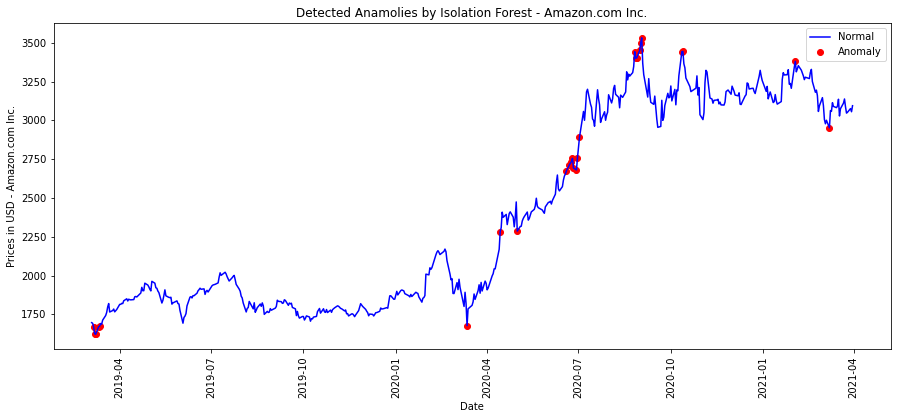

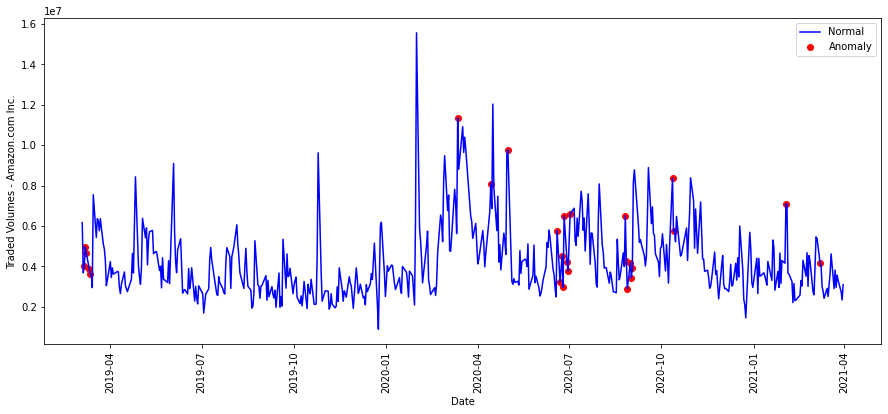

In [ ]:
# Plotting

fig, ax = plt.subplots(figsize=(15,6))

a = amzn_historical_new.loc[amzn_historical_new['anomaly_IsolationForest'] == -1, ['Date', 'Close']] #anomaly

#sns.set_style("darkgrid")
ax.plot(amzn_historical_new['Date'], amzn_historical_new['Close'], color='blue', label = 'Normal')
ax.scatter(a['Date'],a['Close'], color='red', label = 'Anomaly')
plt.legend()
plt.title('Detected Anamolies by Isolation Forest - Amazon.com Inc.')
plt.xlabel('Date')
plt.xticks(rotation=90)
plt.ylabel('Prices in USD - Amazon.com Inc.')
plt.show()

fig, ax = plt.subplots(figsize=(15,6))

a = amzn_historical_new.loc[amzn_historical_new['anomaly_IsolationForest'] == -1, ['Date', 'Volume']] #anomaly

#sns.set_style("darkgrid")
ax.plot(amzn_historical_new['Date'], amzn_historical_new['Volume'], color='blue', label = 'Normal')
ax.scatter(a['Date'],a['Volume'], color='red', label = 'Anomaly')
plt.legend()
plt.xlabel('Date')
plt.xticks(rotation=90)
plt.ylabel('Traded Volumes - Amazon.com Inc.')
plt.show()

### Second method in anomaly detection by Isolation Forest tested on Amazon.com Inc.

In [ ]:
### Second method

model_iforest = IsolationForest(n_estimators=100)
model_iforest

In [ ]:
model_iforest.fit(data)
scores = model_iforest.score_samples(data)
threshold = quantile(scores, 0.05)
threshold

-0.6026359211083421

In [ ]:
scores

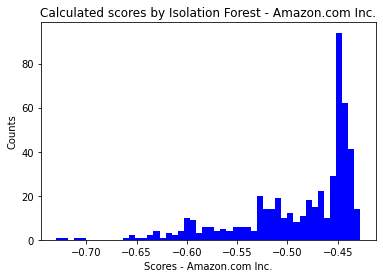

In [ ]:
plt.hist(scores, bins=50, color='blue')
plt.title('Calculated scores by Isolation Forest - Amazon.com Inc.')
plt.xlabel('Scores - Amazon.com Inc.')
plt.ylabel('Counts')
plt.show()

In [ ]:
amzn_historical_new['scores_IsolationForest'] = pd.Series(scores)
amzn_historical_new.head()

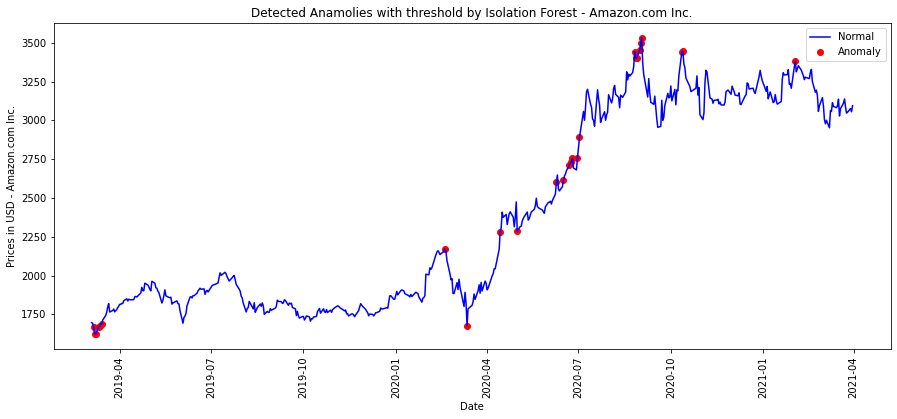

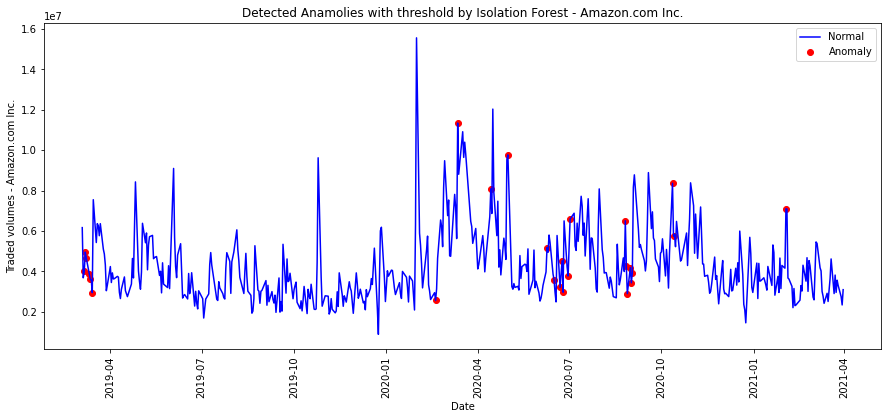

In [ ]:
fig, ax = plt.subplots(figsize=(15,6))

a = amzn_historical_new.loc[amzn_historical_new['scores_IsolationForest'] <= threshold, ['Date', 'Close']] #anomaly

#sns.set_style("darkgrid")
ax.plot(amzn_historical_new['Date'], amzn_historical_new['Close'], color='blue', label = 'Normal')
ax.scatter(a['Date'],a['Close'], color='red', label = 'Anomaly')
plt.legend()
plt.title('Detected Anamolies with threshold by Isolation Forest - Amazon.com Inc.')
plt.xlabel('Date')
plt.xticks(rotation=90)
plt.ylabel('Prices in USD - Amazon.com Inc.')
plt.show()

fig, ax = plt.subplots(figsize=(15,6))

a = amzn_historical_new.loc[amzn_historical_new['scores_IsolationForest'] <= threshold, ['Date', 'Volume']] #anomaly

#sns.set_style("darkgrid")
ax.plot(amzn_historical_new['Date'], amzn_historical_new['Volume'], color='blue', label = 'Normal')
ax.scatter(a['Date'],a['Volume'], color='red', label = 'Anomaly')
plt.legend()
plt.title('Detected Anamolies with threshold by Isolation Forest - Amazon.com Inc.')
plt.xlabel('Date')
plt.xticks(rotation=90)
plt.ylabel('Traded volumes - Amazon.com Inc.')
plt.show()

In [ ]:
# Counting distinct number of anomalies in "traded Volumes"

amzn_historical_new.loc[amzn_historical_new['scores_IsolationForest'] <= threshold,'scores_IsolationForest'].agg(['count'])

count    26
Name: scores_IsolationForest, dtype: int64

In [ ]:
amzn_historical_new_threshold = amzn_historical_new.loc[amzn_historical_new['scores_IsolationForest'].values <= threshold]
amzn_historical_new_threshold

In [ ]:
# Saving the results of anomalies by Isolation Forest by threshold method in G-drive

amzn_historical_new_gdrive_IF_2ndMethod = amzn_historical_new_threshold.to_csv('/content/drive/MyDrive/Colab Notebooks/Results of Anamoly detection/Result_IsolationForest/Result_2ndMethod_IF_AMZN.csv')

### One-Class SVM anomaly detection - Amazon stock

# New Section

In [ ]:
data = amzn_historical_new[['Close']]

sc = MinMaxScaler()
scaled = sc.fit_transform(data)
data = pd.DataFrame(scaled)

# Building and training One-class SVM model

model = OneClassSVM(nu=outliers_fraction, kernel="rbf", gamma=0.01)
model.fit(data)
amzn_historical_new['anomaly_OneClassSVM'] = pd.Series(model.predict(data)) # -1 is anomaly and 1 is normal.

In [ ]:
amzn_historical_new.head()

In [ ]:
# Counting distinct number of anomalies in "Tesla Stock Prices"

amzn_historical_new.loc[amzn_historical_new['anomaly_OneClassSVM'] == -1,'anomaly_OneClassSVM'].agg(['count'])

count    24
Name: anomaly_OneClassSVM, dtype: int64

In [ ]:
anomaly_OCSVM_AMZN = amzn_historical_new.loc[amzn_historical_new['anomaly_OneClassSVM'].values == -1]

In [ ]:
# Saving the results of anomalies by One-Class SVM in G-drive

anomaly_OCSVM_AMZN_gdrive = anomaly_OCSVM_AMZN.to_csv('/content/drive/MyDrive/Colab Notebooks/Results of Anamoly detection/Result_OneClassSVM/Result_OCSVM_AMZN.csv')

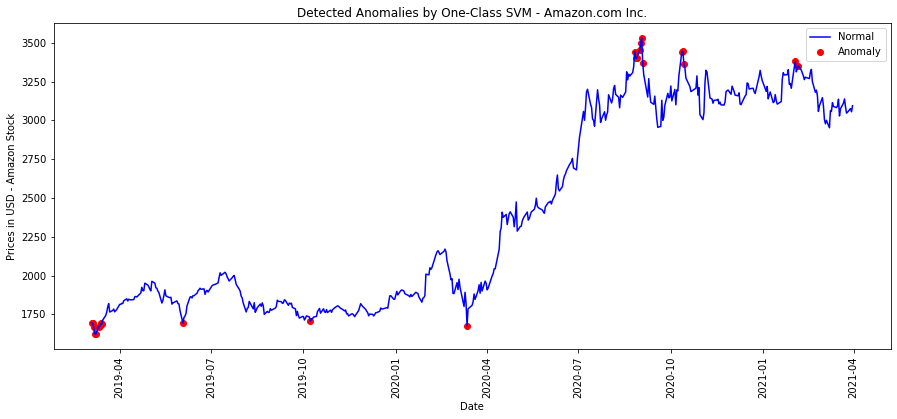

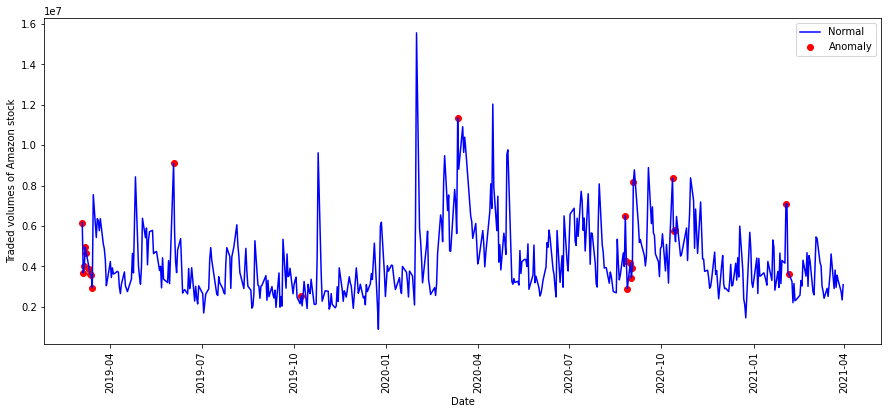

In [ ]:
# Plotting the data
fig, ax = plt.subplots(figsize=(15,6))
a = amzn_historical_new.loc[amzn_historical_new['anomaly_OneClassSVM'] == -1, ['Date', 'Close']] #anomaly

ax.plot(amzn_historical_new['Date'], amzn_historical_new['Close'], color='blue', label='Normal')
ax.scatter(a['Date'],a['Close'], color='red', label='Anomaly')
plt.legend()
plt.title('Detected Anomalies by One-Class SVM - Amazon.com Inc.')
plt.xlabel('Date')
plt.ylabel('Prices in USD - Amazon Stock')
plt.xticks(rotation=90)
plt.show()


fig, ax = plt.subplots(figsize=(15,6))
a = amzn_historical_new.loc[amzn_historical_new['anomaly_OneClassSVM'] == -1, ['Date', 'Volume']] #anomaly

ax.plot(amzn_historical_new['Date'], amzn_historical_new['Volume'], color='blue', label='Normal')
ax.scatter(a['Date'],a['Volume'], color='red', label='Anomaly')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Traded volumes of Amazon stock')
plt.xticks(rotation=90)
plt.show()

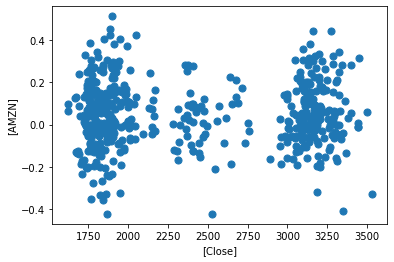

In [ ]:
amzn_historical_new.plot.scatter(['Close'], ['AMZN'], s=50)
plt.show()


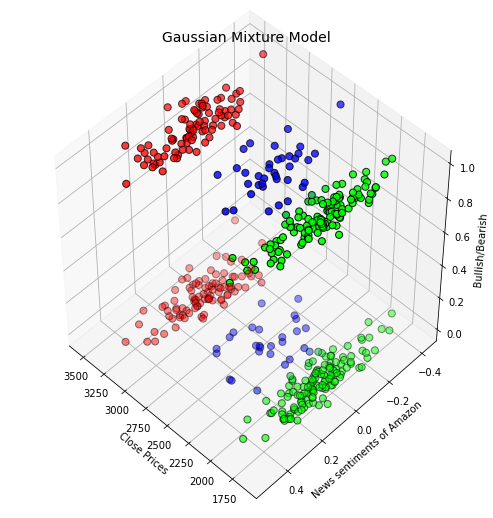

In [ ]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
%matplotlib inline
from sklearn import datasets

X = amzn_historical_new[['Close', 'AMZN', 'Binary_Close_&_Price']]
#Gaussian Mixture Model
gmm = GaussianMixture(n_components=3)
gmm.fit(X)
proba_lists = gmm.predict_proba(X)
#Plotting
colored_arrays = np.matrix(proba_lists)
colored_tuples = [tuple(i.tolist()[0]) for i in colored_arrays]
fig = plt.figure(1, figsize=(7,7))
ax = Axes3D(fig, rect=[0, 0, 0.95, 1], elev=48, azim=134)
ax.scatter(X.iloc[:, 0], X.iloc[:, 1], X.iloc[:, 2], c=colored_tuples, edgecolor="k", s=50)
ax.set_xlabel("Close Prices")
ax.set_ylabel("News sentiments of Amazon")
ax.set_zlabel("Bullish/Bearish")
plt.title("Gaussian Mixture Model", fontsize=14)
plt.show()